# Overview (Candidate)
* Separate male/female from the dataset
* Add medication to the male/female dataset
* Impute NaNs

In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import sys

from scipy import stats
from importlib.metadata import version

# set seaborn theme
sns.set_theme()

# python modules
import utilities as u
import plot

# initializing variables
SEED = 1776

# Create a dictionary of versions
versions = {
    "Python": sys.version.split()[0],
    "Pandas": pd.__version__,
    "NumPy": np.__version__,
    "Seaborn": sns.__version__,
    "Matplot": sys.modules['matplotlib'].__version__,
    "Scipy": sys.modules['scipy'].__version__,
}

# Display as a clean DataFrame
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
print(df_versions)

# # adjust pandas display options to max
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)
# # adjust pandas display options to ensure full display of content
# pd.set_option('display.max_colwidth', None)

   Library  Version
0   Python  3.11.13
1   Pandas    2.3.1
2    NumPy    2.3.2
3  Seaborn   0.13.2
4  Matplot   3.10.5
5    Scipy   1.16.1


## Import Data

In [2]:
# import data
df = pd.read_pickle("../Data/CAN_Heart_Data.pkl")
# display
df.head()

,PreviousTransplantNumber_CAN,WaitListDiagnosisCode_CAN,Gender_CAN,BloodGroup_CAN,Weight_kg_Registrsation_CAN,Height_cm_Registration_CAN,BMI_Listing_CAN,Citizenship_CAN,ResidencyStateRegistration_CAN,EducationLevel_CAN,...,HeartProcedureType_CAN,TransplantYear_CAN,ListingYear_CAN,TransplantSurvivalDay,CrossMatchDone,MismatchLevel_AMIS,MismatchLevel_BMIS,MismatchLevel_DRMIS,MismatchLevel_HLAMIS,BloodGroupMatchLevel
0,0,DILATED MYOPATHY: IDIOPATHIC,M,A,65.771,173.0,22.0470,US Citizen,CA,ATTENDED COLLEGE/TECHNICAL SCHOOL,...,Orthotopic Bicaval,2013,2013,329.0,No,2,2,1,5,Identical
1,0,DILATED MYOPATHY: OTHER SPECIFY,M,O,72.575,185.0,21.1093,US Citizen,TX,HIGH SCHOOL (9-12) or GED,...,Orthotopic Bicaval,2013,2012,2592.0,Yes,1,2,2,5,Identical
2,0,DILATED MYOPATHY: ISCHEMIC,M,O,106.000,175.0,34.5096,US Citizen,NY,ATTENDED COLLEGE/TECHNICAL SCHOOL,...,Orthotopic Bicaval,2013,2012,2913.0,Yes,0,1,2,3,Identical
3,0,DILATED MYOPATHY: ISCHEMIC,M,A,111.000,178.0,35.0335,US Citizen,NY,HIGH SCHOOL (9-12) or GED,...,Orthotopic Bicaval,2013,2012,1225.0,Yes,2,2,2,6,Identical
4,0,DILATED MYOPATHY: IDIOPATHIC,M,A,72.000,172.0,24.3375,US Citizen,NC,ASSOCIATE/BACHELOR DEGREE,...,Orthotopic Bicaval,2013,2012,2785.0,Yes,0,2,2,4,Identical


In [3]:
df.info(max_cols=df.shape[1])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30298 entries, 0 to 30297
Data columns (total 146 columns):
 #    Column                                        Non-Null Count  Dtype   
---   ------                                        --------------  -----   
 0    PreviousTransplantNumber_CAN                  30298 non-null  category
 1    WaitListDiagnosisCode_CAN                     30298 non-null  category
 2    Gender_CAN                                    30298 non-null  category
 3    BloodGroup_CAN                                30298 non-null  category
 4    Weight_kg_Registrsation_CAN                   30248 non-null  float64 
 5    Height_cm_Registration_CAN                    30185 non-null  float64 
 6    BMI_Listing_CAN                               30183 non-null  float64 
 7    Citizenship_CAN                               30298 non-null  category
 8    ResidencyStateRegistration_CAN                30298 non-null  category
 9    EducationLevel_CAN                   

## Gender

In [4]:
# nans
u.any_nans(df)

--- Missing Values Found () (Total Rows: 30,298) ---
                                     Count Percentage
HemodynamicsRegistration_PCW_CAN      2838    9.3670%
HemodynamicsTransplant_PCW_CAN        2225    7.3437%
HemodynamicsRegistration_CO_CAN       1730    5.7099%
HemodynamicsRegistration_PA_MN_CAN    1390    4.5878%
FunctionalStatusTransplant_CAN        1374    4.5350%
HemodynamicsTransplant_CO_CAN         1370    4.5218%
HemodynamicsTransplant_PA_MN_CAN      1183    3.9045%
HemodynamicsRegistration_PA_DIA_CAN   1072    3.5382%
HemodynamicsRegistration_SYS_CAN      1050    3.4656%
FunctionalStatusRegistration_CAN       973    3.2114%
HemodynamicsTransplant_PA_DIA_CAN      884    2.9177%
HemodynamicsTransplant_SYS_CAN         860    2.8385%
TotalBilirubinTransplant_CAN           118    0.3895%
BMI_Listing_CAN                        115    0.3796%
Height_cm_Registration_CAN             113    0.3730%
CreatinineRegistration_CAN             103    0.3400%
CreatinineTransplant_CAN     

In [5]:
df.Gender_CAN.value_counts(dropna=False)

Gender_CAN
M    22234
F     8064
Name: count, dtype: int64

In [6]:
df_m = df[df.Gender_CAN == 'M'].copy()
df_f = df[df.Gender_CAN == 'F'].copy()
#
df_m.shape, df_f.shape

((22234, 146), (8064, 146))

### User Function(s)

In [7]:
def plot_histogram(data, column, bins=30, txt='', title_font=20, tick_font=10, KDE=True):
    """
    Plotting histograms of multiple columns in a single figure. 
    """
    plt.figure(figsize=(10, 6))  # width, height in inches
    # plot
    ax = sns.histplot(
        data=data,
        x=column,
        kde=KDE,
        bins=bins
    )
    # aesthetics
    plt.title(f"{txt}", fontsize=title_font)
    plt.ylabel("Frequency", fontsize=tick_font, fontweight='bold')
    plt.xlabel(column, fontsize=tick_font, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Hemodynamics Registration

#### Male

In [8]:
# info
features = u.get_feature_info(df_m, 'HemodynamicsRegistration', cat=False)

                                       count       mean        std   min   25%   50%   75%    max
HemodynamicsRegistration_CO_CAN      20984.0   4.424512   1.348649  0.39   3.5   4.3   5.2   15.0
HemodynamicsRegistration_PA_DIA_CAN  21503.0  20.928066   8.782817  0.00  15.0  20.0  27.0   83.0
HemodynamicsRegistration_PA_MN_CAN   21236.0  29.169335  10.317627  0.00  21.0  29.0  36.0   87.0
HemodynamicsRegistration_PCW_CAN     20147.0  19.631905   8.885775  0.00  13.0  20.0  26.0   50.0
HemodynamicsRegistration_SYS_CAN     21521.0  42.791971  14.465370  0.00  32.0  42.0  53.0  123.0

:::: NaN Count:
HemodynamicsRegistration_CO_CAN        1250
HemodynamicsRegistration_PA_DIA_CAN     731
HemodynamicsRegistration_PA_MN_CAN      998
HemodynamicsRegistration_PCW_CAN       2087
HemodynamicsRegistration_SYS_CAN        713 



Those hemodynamic variables (Cardiac Output, Pulmonary Artery pressures, and Wedge pressure) are notorious for having missing data in donor registries because they require invasive Swan-Ganz catheterization, which isn't performed on every donor.

* CO (Cardiac Output)
* PA_DIA (Pulmonary Artery Diastolic)
* PA_MN (Pulmonary Artery Mean)
* PCW (Pulmonary Capillary Wedge)
* SYS (Systemic Arterial Systolic)

In [9]:
df_m[features].corr()

,HemodynamicsRegistration_CO_CAN,HemodynamicsRegistration_PA_DIA_CAN,HemodynamicsRegistration_PA_MN_CAN,HemodynamicsRegistration_PCW_CAN,HemodynamicsRegistration_SYS_CAN
HemodynamicsRegistration_CO_CAN,1.000000,-0.237844,-0.216292,-0.261240,-0.178086
HemodynamicsRegistration_PA_DIA_CAN,-0.237844,1.000000,0.895252,0.822046,0.783360
HemodynamicsRegistration_PA_MN_CAN,-0.216292,0.895252,1.000000,0.838901,0.919844
HemodynamicsRegistration_PCW_CAN,-0.261240,0.822046,0.838901,1.000000,0.763253
HemodynamicsRegistration_SYS_CAN,-0.178086,0.783360,0.919844,0.763253,1.000000


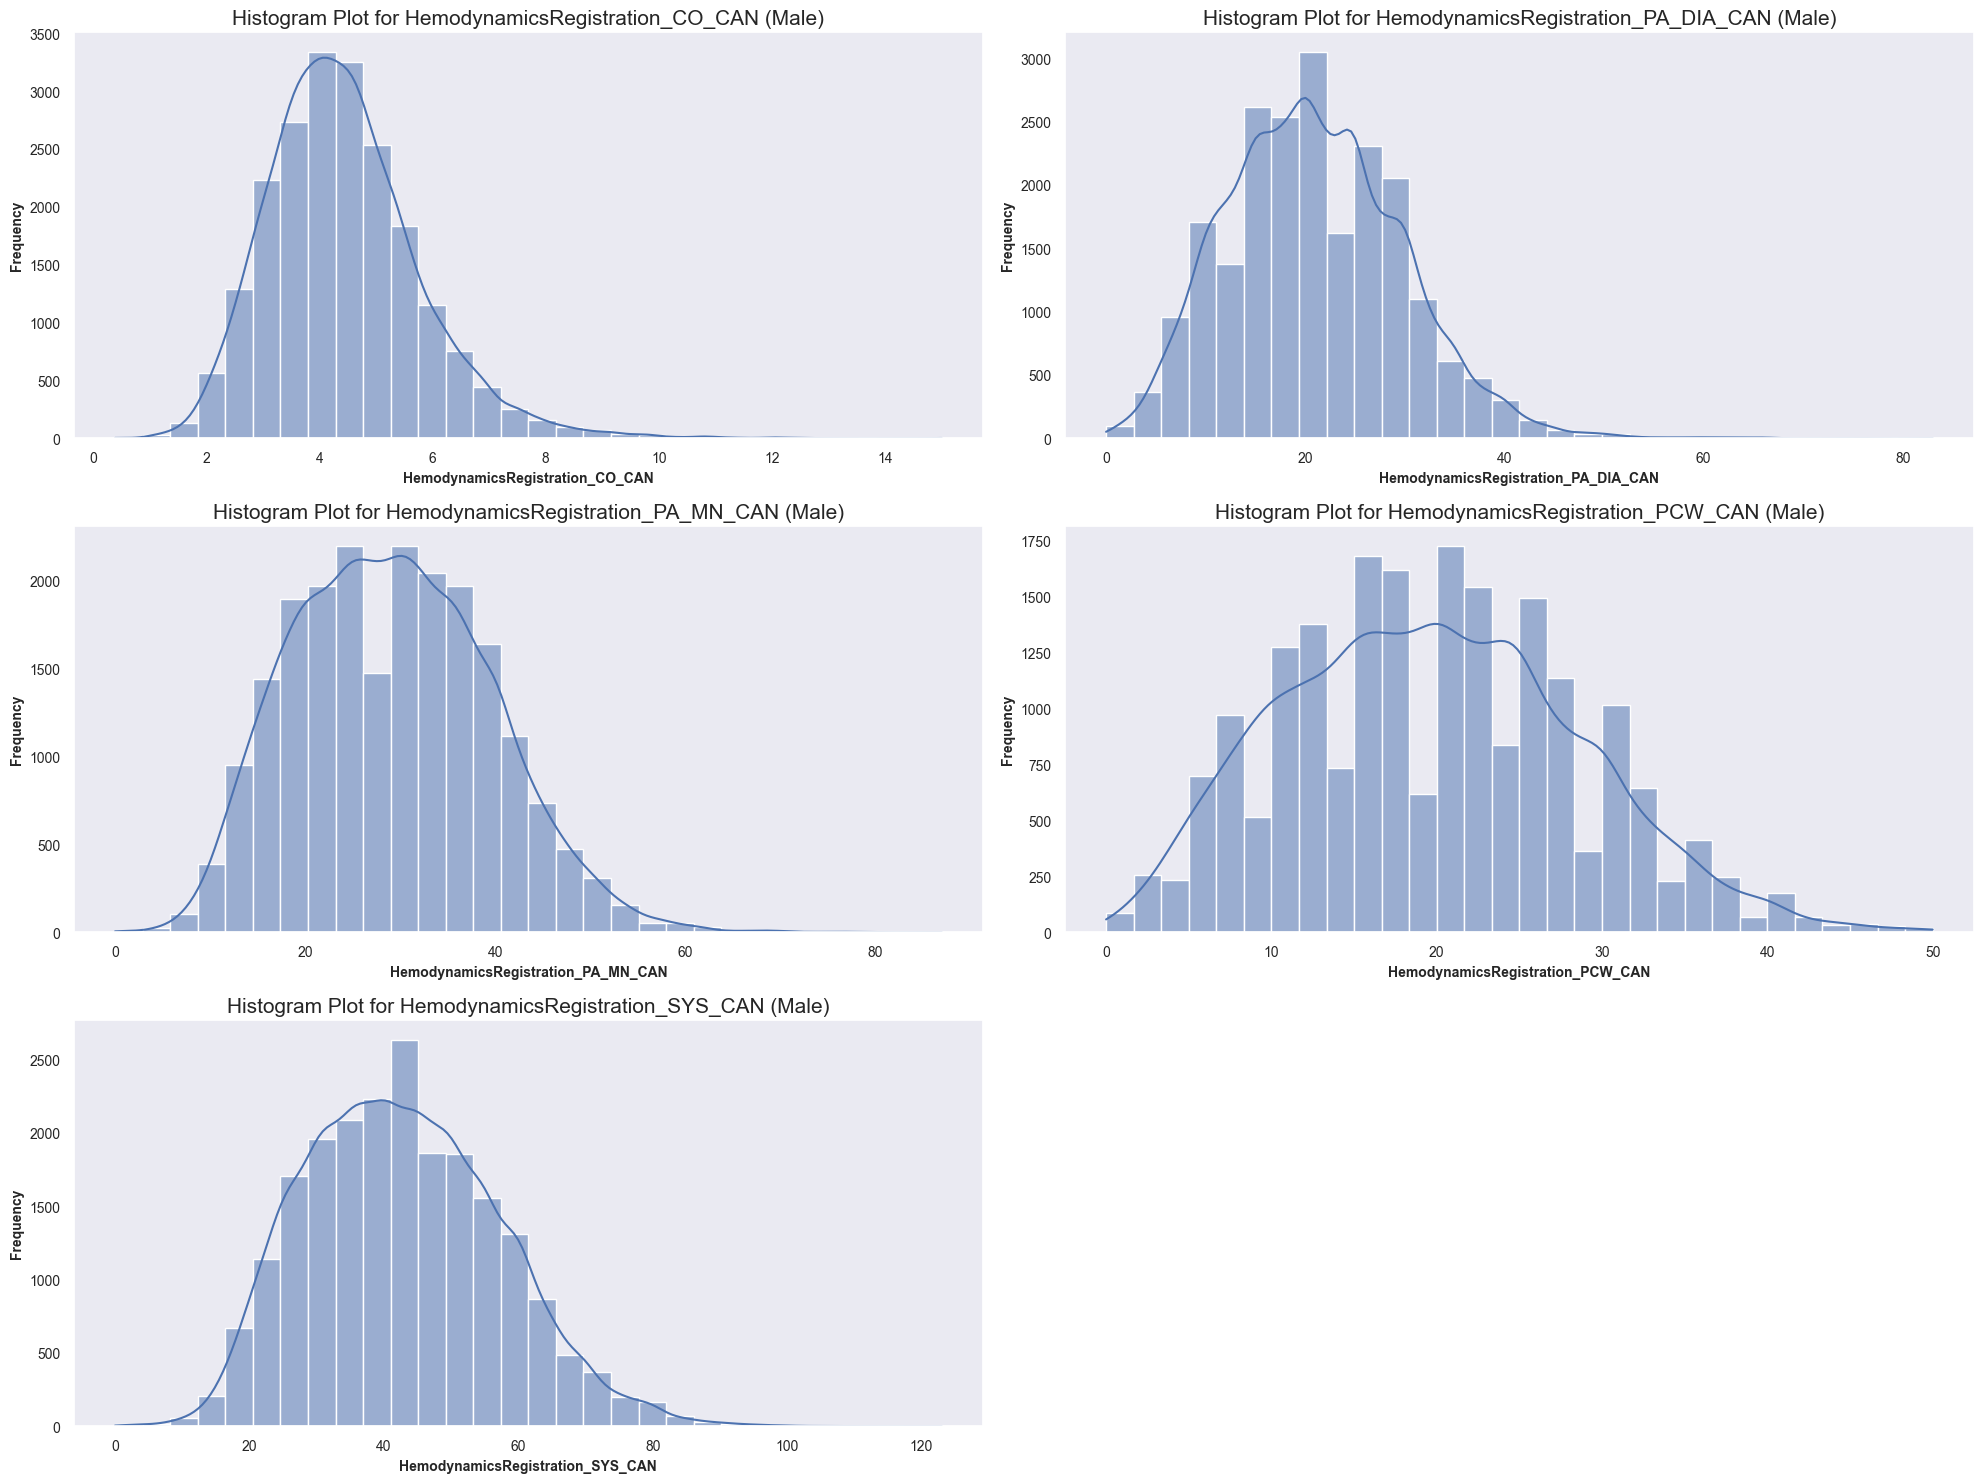

In [10]:
plot.plot_histogram(df_m, features, bins=30, txt='(Male)')

In [11]:
u.check_informative_missingness(df_m, 'HemodynamicsRegistration_CO_CAN', txt='Male')

--- Missingness (Male): HemodynamicsRegistration_CO_CAN ---
Group Sizes:    (Unknown=1,250, Known=20,984)
Mean survival:  (Unknown=1,403.1d, Known=1,438.5d)
Difference:     -35.4 days

--- Welch's t-test Analysis ---
ρ-Value: 0.3200
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.0306 (Negligible)
95% CI:        [-0.0877, 0.0264]
Result: Likely Random Missingness (Effect size not significant)



In [12]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsRegistration_CO_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsRegistration_CO_CAN ---
Pearson r=-0.002, p=0.7575 & Approx. Variance Explained=0.000%
Spearman r=0.000, p=0.9884 & Approx. Variance Explained=0.000%



#### Median Imputation

In [13]:
# Median impute
df_m['HemodynamicsRegistration_CO_CAN'] = df_m['HemodynamicsRegistration_CO_CAN'].fillna(
    df_m['HemodynamicsRegistration_CO_CAN'].median()
)

In [14]:
u.check_informative_missingness(df_m, 'HemodynamicsRegistration_PA_DIA_CAN', txt='Male')

--- Missingness (Male): HemodynamicsRegistration_PA_DIA_CAN ---
Group Sizes:    (Unknown=731, Known=21,503)
Mean survival:  (Unknown=1,325.6d, Known=1,440.3d)
Difference:     -114.7 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0135
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.0991 (Negligible)
95% CI:        [-0.1729, -0.0254]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



#### The "Shadow Variable" (Indicator) + Median Imputation

In [15]:
# impute: median and use new feature for NANS
df_m['HemodynamicsRegistration_PA_DIA_IsMissing'] = df_m['HemodynamicsRegistration_PA_DIA_CAN'].isna().astype(int)
df_m['HemodynamicsRegistration_PA_DIA_CAN'] = df_m['HemodynamicsRegistration_PA_DIA_CAN'].fillna(
    df_m['HemodynamicsRegistration_PA_DIA_CAN'].median()
)

In [16]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsRegistration_PA_DIA_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsRegistration_PA_DIA_CAN ---
Pearson r=0.037, p=4.318e-08 & Approx. Variance Explained=0.135%
Spearman r=0.033, p=1.075e-06 & Approx. Variance Explained=0.107%



In [17]:
u.check_informative_missingness(df_m, 'HemodynamicsRegistration_PA_MN_CAN', txt='Male')

--- Missingness (Male): HemodynamicsRegistration_PA_MN_CAN ---
Group Sizes:    (Unknown=998, Known=21,236)
Mean survival:  (Unknown=1,481.3d, Known=1,434.4d)
Difference:     46.9 days

--- Welch's t-test Analysis ---
ρ-Value: 0.2494
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     0.0405 (Negligible)
95% CI:        [-0.0230, 0.1040]
Result: Likely Random Missingness (Effect size not significant)



In [18]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsRegistration_PA_MN_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsRegistration_PA_MN_CAN ---
Pearson r=0.046, p=2.04e-11 & Approx. Variance Explained=0.211%
Spearman r=0.041, p=2.324e-09 & Approx. Variance Explained=0.168%



#### Median Imputation

In [19]:
# Median impute
df_m['HemodynamicsRegistration_PA_MN_CAN'] = df_m['HemodynamicsRegistration_PA_MN_CAN'].fillna(
    df_m['HemodynamicsRegistration_PA_MN_CAN'].median()
)

In [20]:
u.check_informative_missingness(df_m, 'HemodynamicsRegistration_PCW_CAN', txt='Male')

--- Missingness (Male): HemodynamicsRegistration_PCW_CAN ---
Group Sizes:    (Unknown=2,087, Known=20,147)
Mean survival:  (Unknown=1,442.3d, Known=1,435.9d)
Difference:     6.4 days

--- Welch's t-test Analysis ---
ρ-Value: 0.8149
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     0.0055 (Negligible)
95% CI:        [-0.0395, 0.0506]
Result: Likely Random Missingness (Effect size not significant)



In [21]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsRegistration_PCW_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsRegistration_PCW_CAN ---
Pearson r=0.049, p=4.789e-12 & Approx. Variance Explained=0.237%
Spearman r=0.044, p=4e-10 & Approx. Variance Explained=0.194%



#### Median Imputation

In [22]:
# Median impute
df_m['HemodynamicsRegistration_PCW_CAN'] = df_m['HemodynamicsRegistration_PCW_CAN'].fillna(
    df_m['HemodynamicsRegistration_PCW_CAN'].median()
)

In [23]:
u.check_informative_missingness(df_m, 'HemodynamicsRegistration_SYS_CAN', txt='Male')

--- Missingness (Male): HemodynamicsRegistration_SYS_CAN ---
Group Sizes:    (Unknown=713, Known=21,521)
Mean survival:  (Unknown=1,321.7d, Known=1,440.3d)
Difference:     -118.6 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0115
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.1026 (Negligible)
95% CI:        [-0.1772, -0.0279]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [24]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsRegistration_SYS_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsRegistration_SYS_CAN ---
Pearson r=0.046, p=2.087e-11 & Approx. Variance Explained=0.208%
Spearman r=0.042, p=6.413e-10 & Approx. Variance Explained=0.177%



#### The "Shadow Variable" (Indicator) + Median Imputation

In [25]:
# impute: median and use new feature for NANS
df_m['HemodynamicsRegistration_SYS_IsMissing'] = df_m['HemodynamicsRegistration_SYS_CAN'].isna().astype(int)
df_m['HemodynamicsRegistration_SYS_CAN'] = df_m['HemodynamicsRegistration_SYS_CAN'].fillna(
    df_m['HemodynamicsRegistration_SYS_CAN'].median()
)

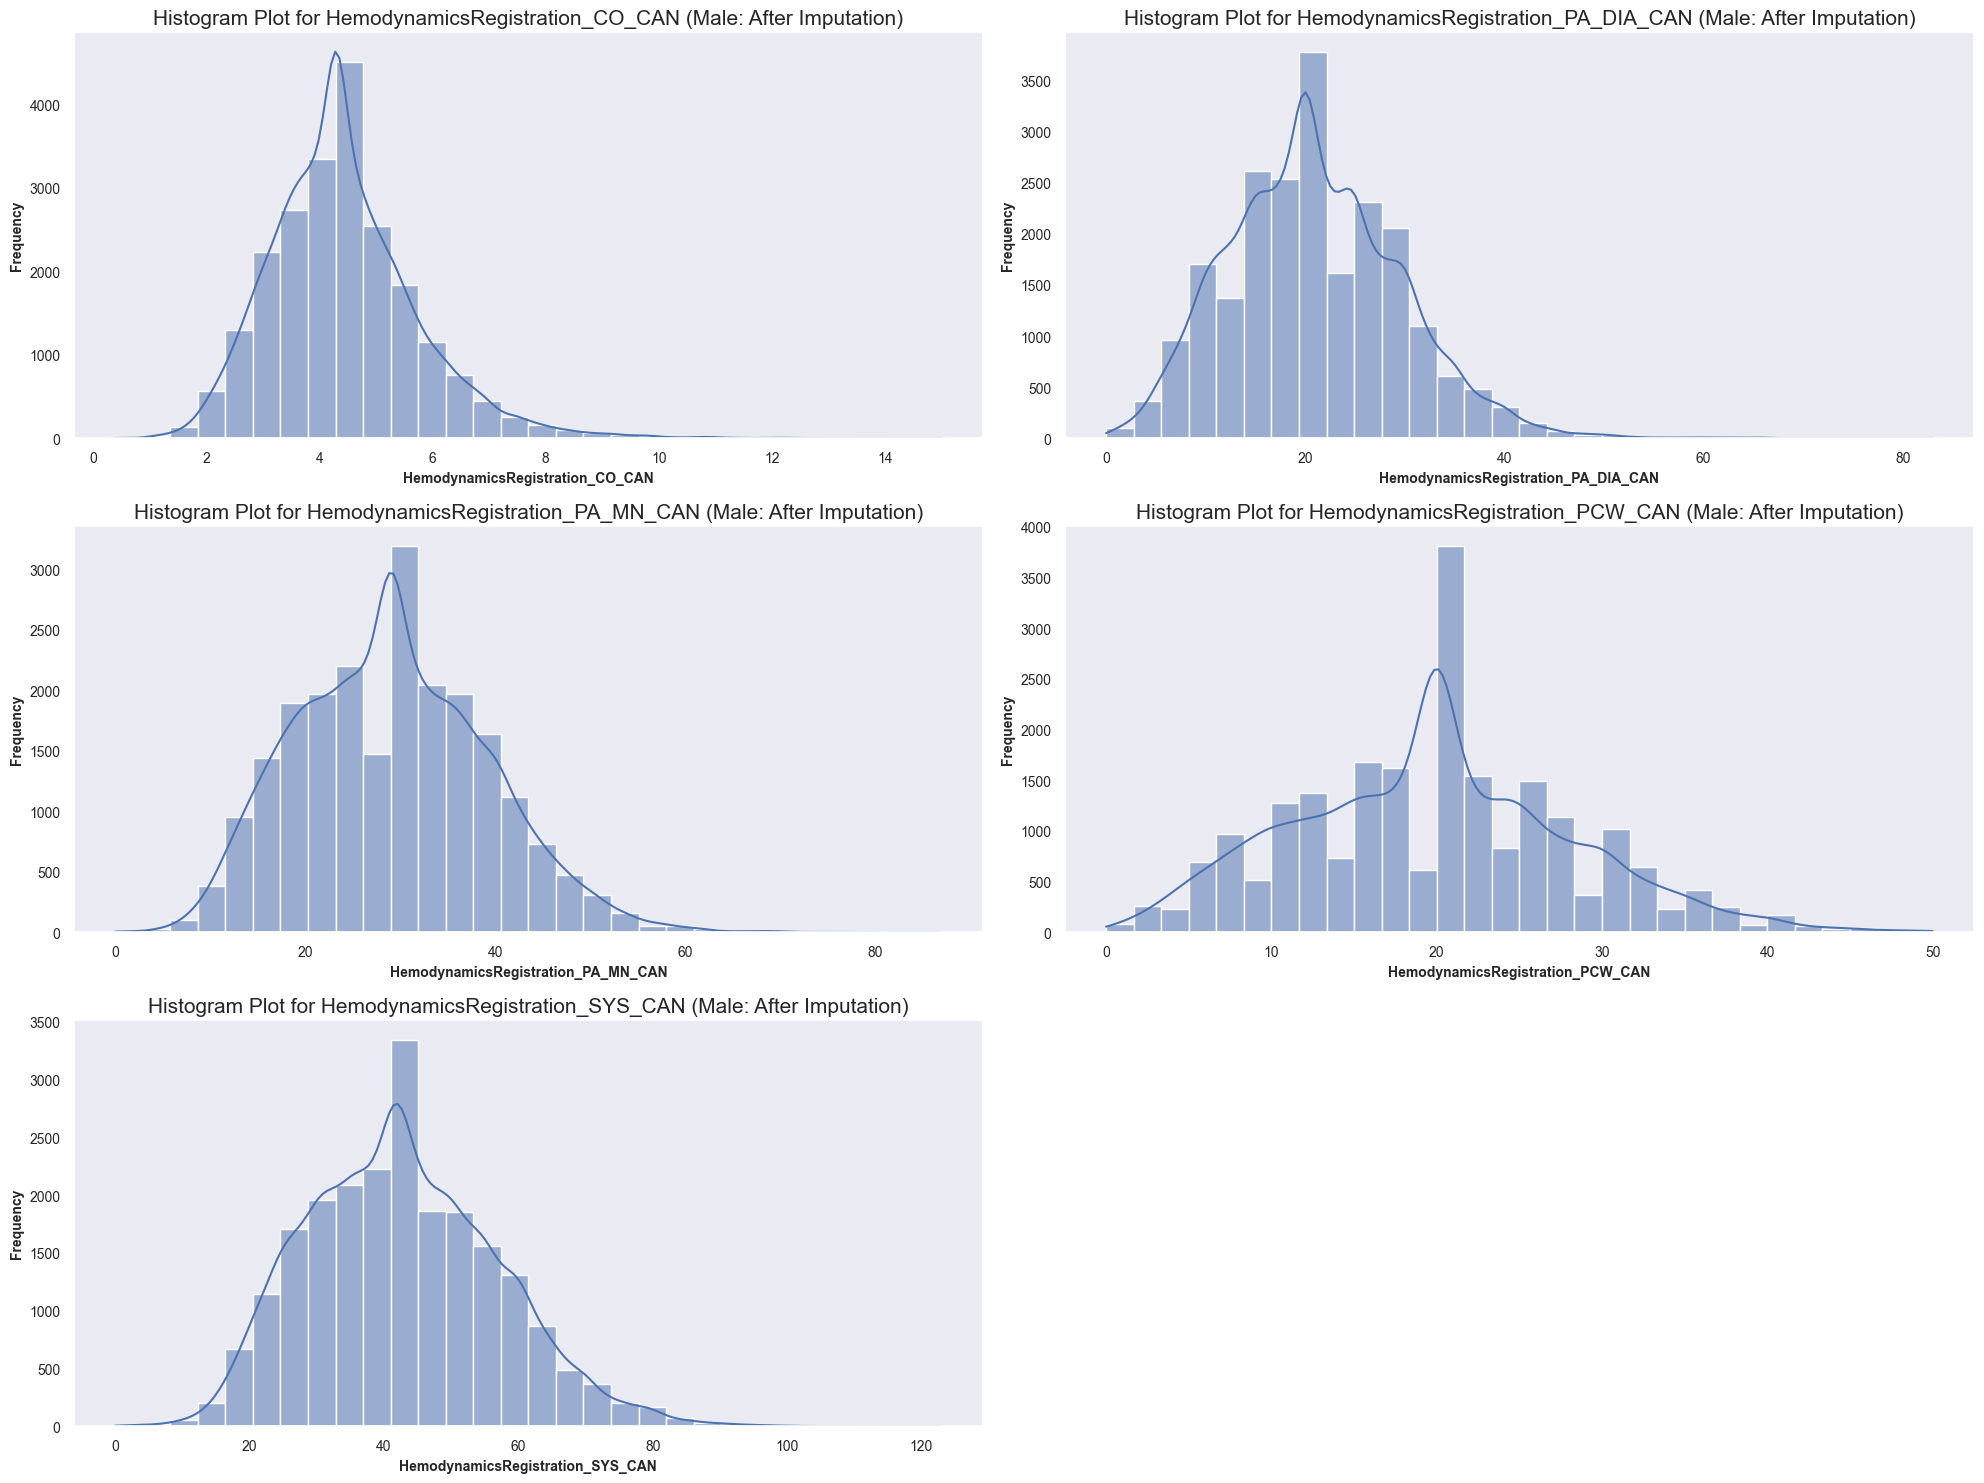

In [26]:
plot.plot_histogram(df_m, features, bins=30, txt='(Male: After Imputation)')

#### **Note:** Use PCA for hemodynamic variables since there are some features that are highly correlated.

In [27]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# scale for PCA
X_scaled = StandardScaler().fit_transform(df_m[features].values)

# PCA
pca = PCA(n_components=0.9, random_state=SEED).fit(X_scaled)  # 90% variance
print(f"Components: {pca.n_components_}")
print(f"Explained variance: {pca.explained_variance_ratio_}")

# Add to dataframe
pca_scores = pca.transform(X_scaled)
for i in range(pca.n_components_):
    df_m[f'PC{i+1}_hemo_registration'] = pca_scores[:, i]

# drop columns
df_m = df_m.drop(columns=features)
# shape
df_m.shape

Components: 3
Explained variance: [0.70662959 0.18640263 0.05567453]


(22234, 146)

#### Female

In [28]:
# info
features = u.get_feature_info(df_f, 'HemodynamicsRegistration', cat=False)

                                      count       mean        std   min      25%    50%   75%    max
HemodynamicsRegistration_CO_CAN      7584.0   3.820094   1.228912  0.91   2.9700   3.68   4.5   15.0
HemodynamicsRegistration_PA_DIA_CAN  7723.0  19.802667   8.379385  0.00  14.0000  19.00  25.0   91.0
HemodynamicsRegistration_PA_MN_CAN   7672.0  27.739586   9.853808  4.00  20.9175  27.00  34.0   96.0
HemodynamicsRegistration_PCW_CAN     7313.0  18.210516   8.418194  0.00  12.0000  18.00  24.0   50.0
HemodynamicsRegistration_SYS_CAN     7727.0  40.676200  13.576105  0.00  31.0000  40.00  50.0  130.0

:::: NaN Count:
HemodynamicsRegistration_CO_CAN        480
HemodynamicsRegistration_PA_DIA_CAN    341
HemodynamicsRegistration_PA_MN_CAN     392
HemodynamicsRegistration_PCW_CAN       751
HemodynamicsRegistration_SYS_CAN       337 



In [29]:
df_f[features].corr()

,HemodynamicsRegistration_CO_CAN,HemodynamicsRegistration_PA_DIA_CAN,HemodynamicsRegistration_PA_MN_CAN,HemodynamicsRegistration_PCW_CAN,HemodynamicsRegistration_SYS_CAN
HemodynamicsRegistration_CO_CAN,1.000000,-0.204048,-0.177482,-0.235581,-0.129799
HemodynamicsRegistration_PA_DIA_CAN,-0.204048,1.000000,0.884069,0.820830,0.789169
HemodynamicsRegistration_PA_MN_CAN,-0.177482,0.884069,1.000000,0.826852,0.909595
HemodynamicsRegistration_PCW_CAN,-0.235581,0.820830,0.826852,1.000000,0.751176
HemodynamicsRegistration_SYS_CAN,-0.129799,0.789169,0.909595,0.751176,1.000000


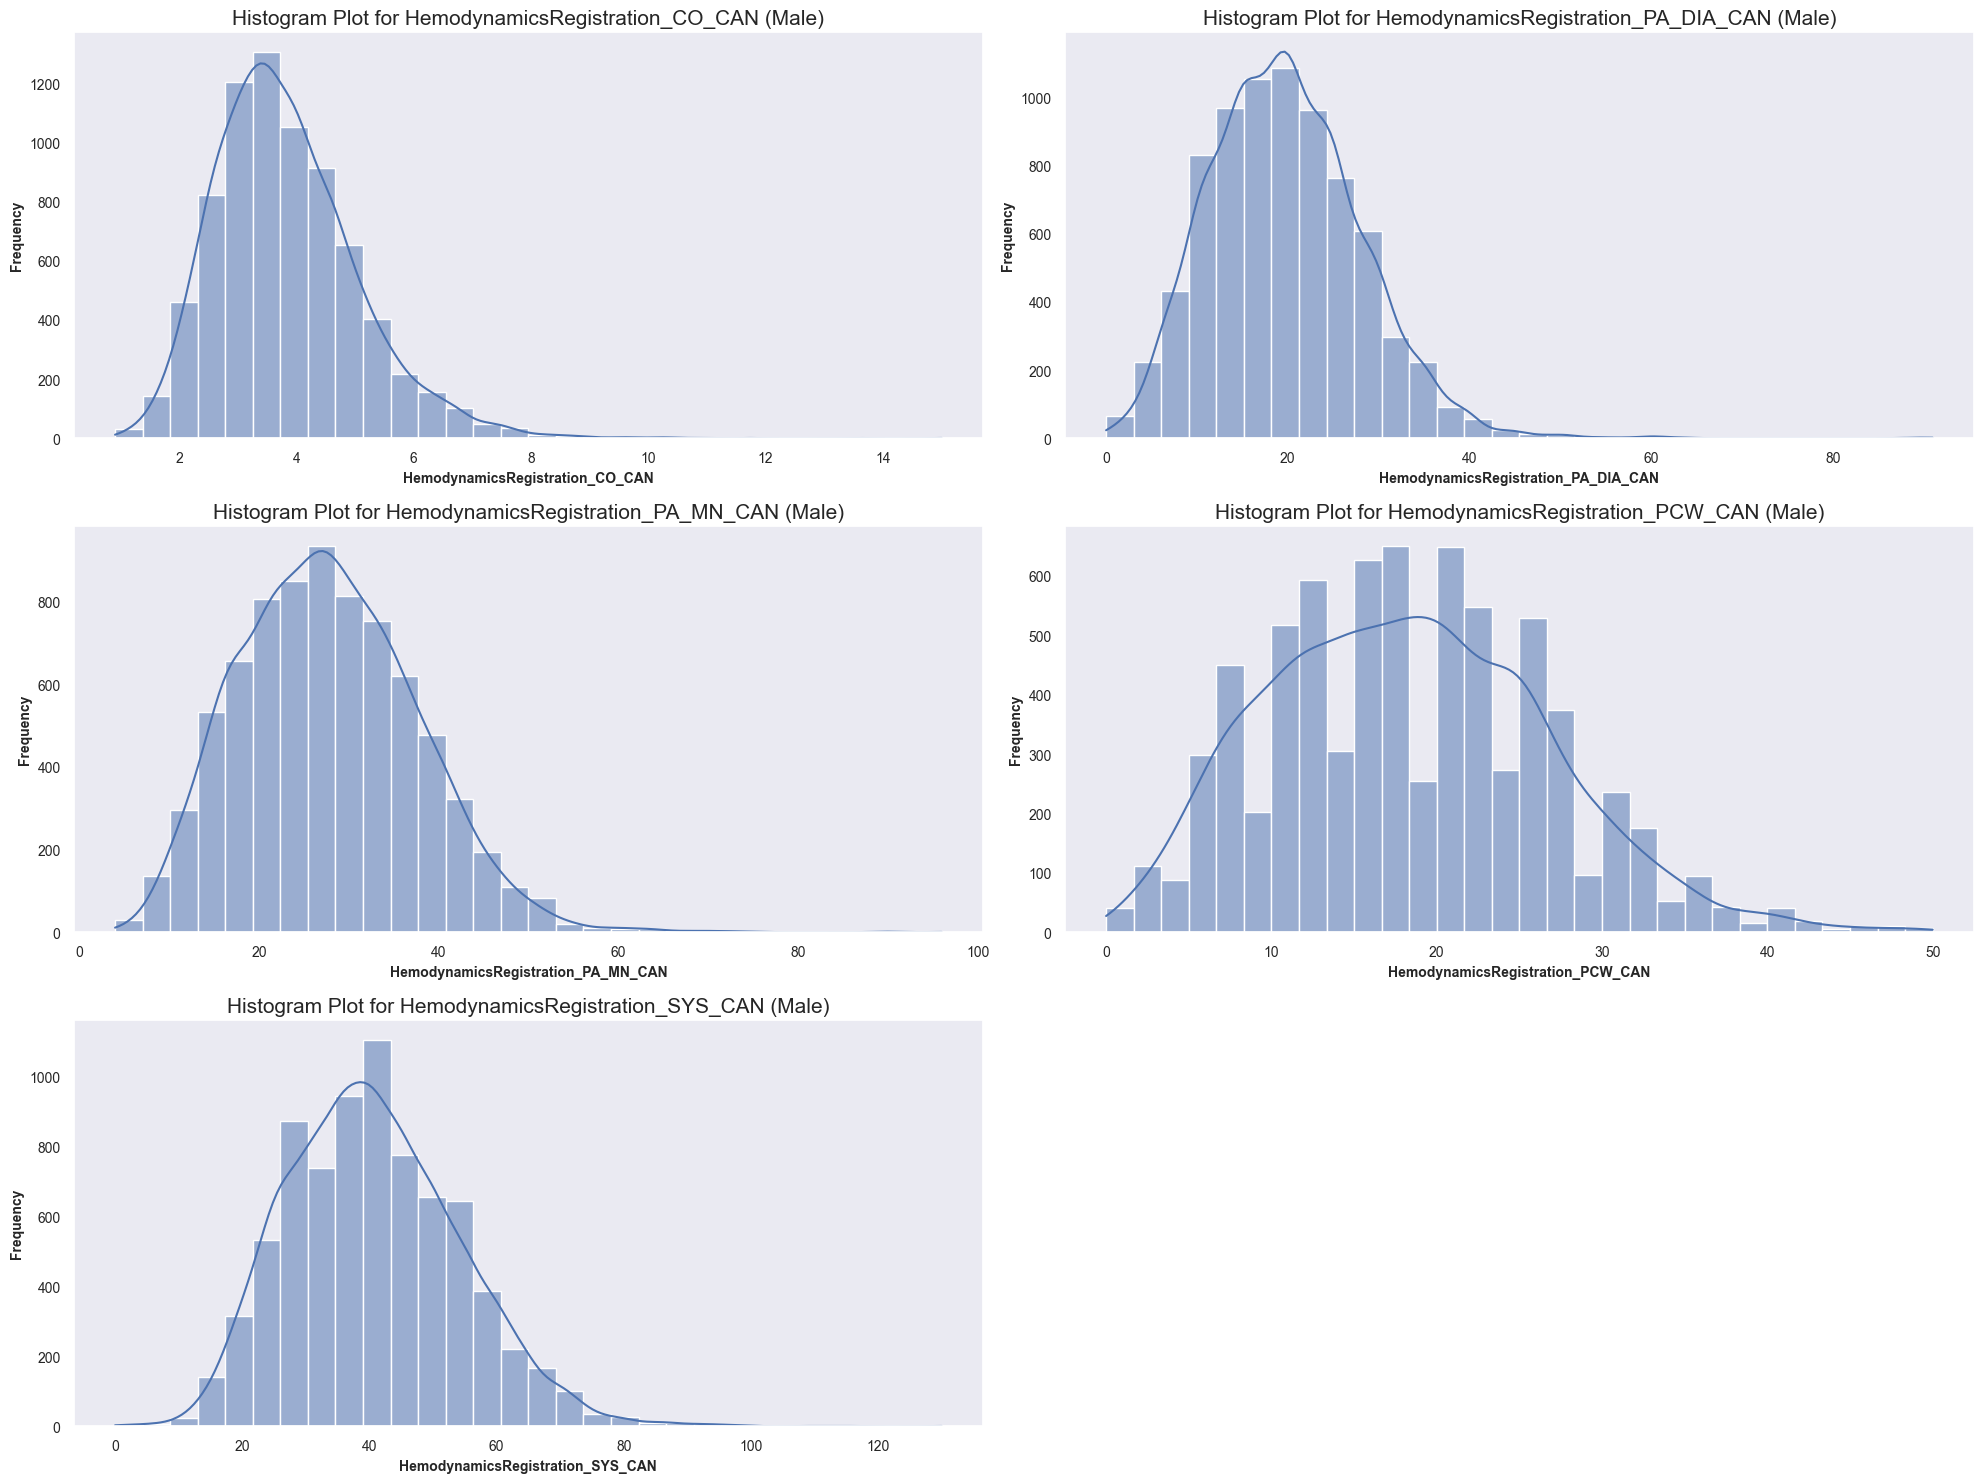

In [30]:
plot.plot_histogram(df_f, features, bins=30, txt='(Male)')

In [31]:
u.check_informative_missingness(df_f, 'HemodynamicsRegistration_CO_CAN', txt='Female')

--- Missingness (Female): HemodynamicsRegistration_CO_CAN ---
Group Sizes:    (Unknown=480, Known=7,584)
Mean survival:  (Unknown=1,490.4d, Known=1,420.0d)
Difference:     70.4 days

--- Welch's t-test Analysis ---
ρ-Value: 0.2262
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     0.0611 (Negligible)
95% CI:        [-0.0312, 0.1533]
Result: Likely Random Missingness (Effect size not significant)



In [32]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsRegistration_CO_CAN', txt='Female')

--- Value Predicts Survival (Female): HemodynamicsRegistration_CO_CAN ---
Pearson r=-0.025, p=0.03231 & Approx. Variance Explained=0.060%
Spearman r=-0.024, p=0.0392 & Approx. Variance Explained=0.056%



#### Median Imputation

In [33]:
# Median impute
df_f['HemodynamicsRegistration_CO_CAN'] = df_f['HemodynamicsRegistration_CO_CAN'].fillna(
    df_f['HemodynamicsRegistration_CO_CAN'].median()
)

In [34]:
u.check_informative_missingness(df_f, 'HemodynamicsRegistration_PA_DIA_CAN', txt='Female')

--- Missingness (Female): HemodynamicsRegistration_PA_DIA_CAN ---
Group Sizes:    (Unknown=341, Known=7,723)
Mean survival:  (Unknown=1,428.5d, Known=1,424.0d)
Difference:     4.4 days

--- Welch's t-test Analysis ---
ρ-Value: 0.9485
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     0.0039 (Negligible)
95% CI:        [-0.1046, 0.1123]
Result: Likely Random Missingness (Effect size not significant)



In [35]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsRegistration_PA_DIA_CAN', txt='Female')

--- Value Predicts Survival (Female): HemodynamicsRegistration_PA_DIA_CAN ---
Pearson r=0.046, p=4.648e-05 & Approx. Variance Explained=0.215%
Spearman r=0.045, p=8.547e-05 & Approx. Variance Explained=0.200%



#### Median Imputation

In [36]:
# Median impute
df_f['HemodynamicsRegistration_PA_DIA_CAN'] = df_f['HemodynamicsRegistration_PA_DIA_CAN'].fillna(
    df_f['HemodynamicsRegistration_PA_DIA_CAN'].median()
)

In [37]:
u.check_informative_missingness(df_f, 'HemodynamicsRegistration_PA_MN_CAN', txt='Female')

--- Missingness (Female): HemodynamicsRegistration_PA_MN_CAN ---
Group Sizes:    (Unknown=392, Known=7,672)
Mean survival:  (Unknown=1,566.9d, Known=1,416.9d)
Difference:     150.0 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0245
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     0.1301 (Negligible)
95% CI:        [0.0286, 0.2316]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



#### Median Imputation

In [38]:
# Median impute
df_f['HemodynamicsRegistration_PA_MN_CAN'] = df_f['HemodynamicsRegistration_PA_MN_CAN'].fillna(
    df_f['HemodynamicsRegistration_PA_MN_CAN'].median()
)

In [39]:
u.check_informative_missingness(df_f, 'HemodynamicsRegistration_PCW_CAN', txt='Female')

--- Missingness (Female): HemodynamicsRegistration_PCW_CAN ---
Group Sizes:    (Unknown=751, Known=7,313)
Mean survival:  (Unknown=1,455.1d, Known=1,421.0d)
Difference:     34.1 days

--- Welch's t-test Analysis ---
ρ-Value: 0.4569
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     0.0295 (Negligible)
95% CI:        [-0.0456, 0.1046]
Result: Likely Random Missingness (Effect size not significant)



#### Median Imputation

In [40]:
# Median impute
df_f['HemodynamicsRegistration_PCW_CAN'] = df_f['HemodynamicsRegistration_PCW_CAN'].fillna(
    df_f['HemodynamicsRegistration_PCW_CAN'].median()
)

In [41]:
u.check_informative_missingness(df_f, 'HemodynamicsRegistration_SYS_CAN', txt='Female')

--- Missingness (Female): HemodynamicsRegistration_SYS_CAN ---
Group Sizes:    (Unknown=337, Known=7,727)
Mean survival:  (Unknown=1,417.4d, Known=1,424.5d)
Difference:     -7.1 days

--- Welch's t-test Analysis ---
ρ-Value: 0.9179
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.0062 (Negligible)
95% CI:        [-0.1152, 0.1029]
Result: Likely Random Missingness (Effect size not significant)



#### Median Imputation

In [42]:
# Median impute
df_f['HemodynamicsRegistration_SYS_CAN'] = df_f['HemodynamicsRegistration_SYS_CAN'].fillna(
    df_f['HemodynamicsRegistration_SYS_CAN'].median()
)

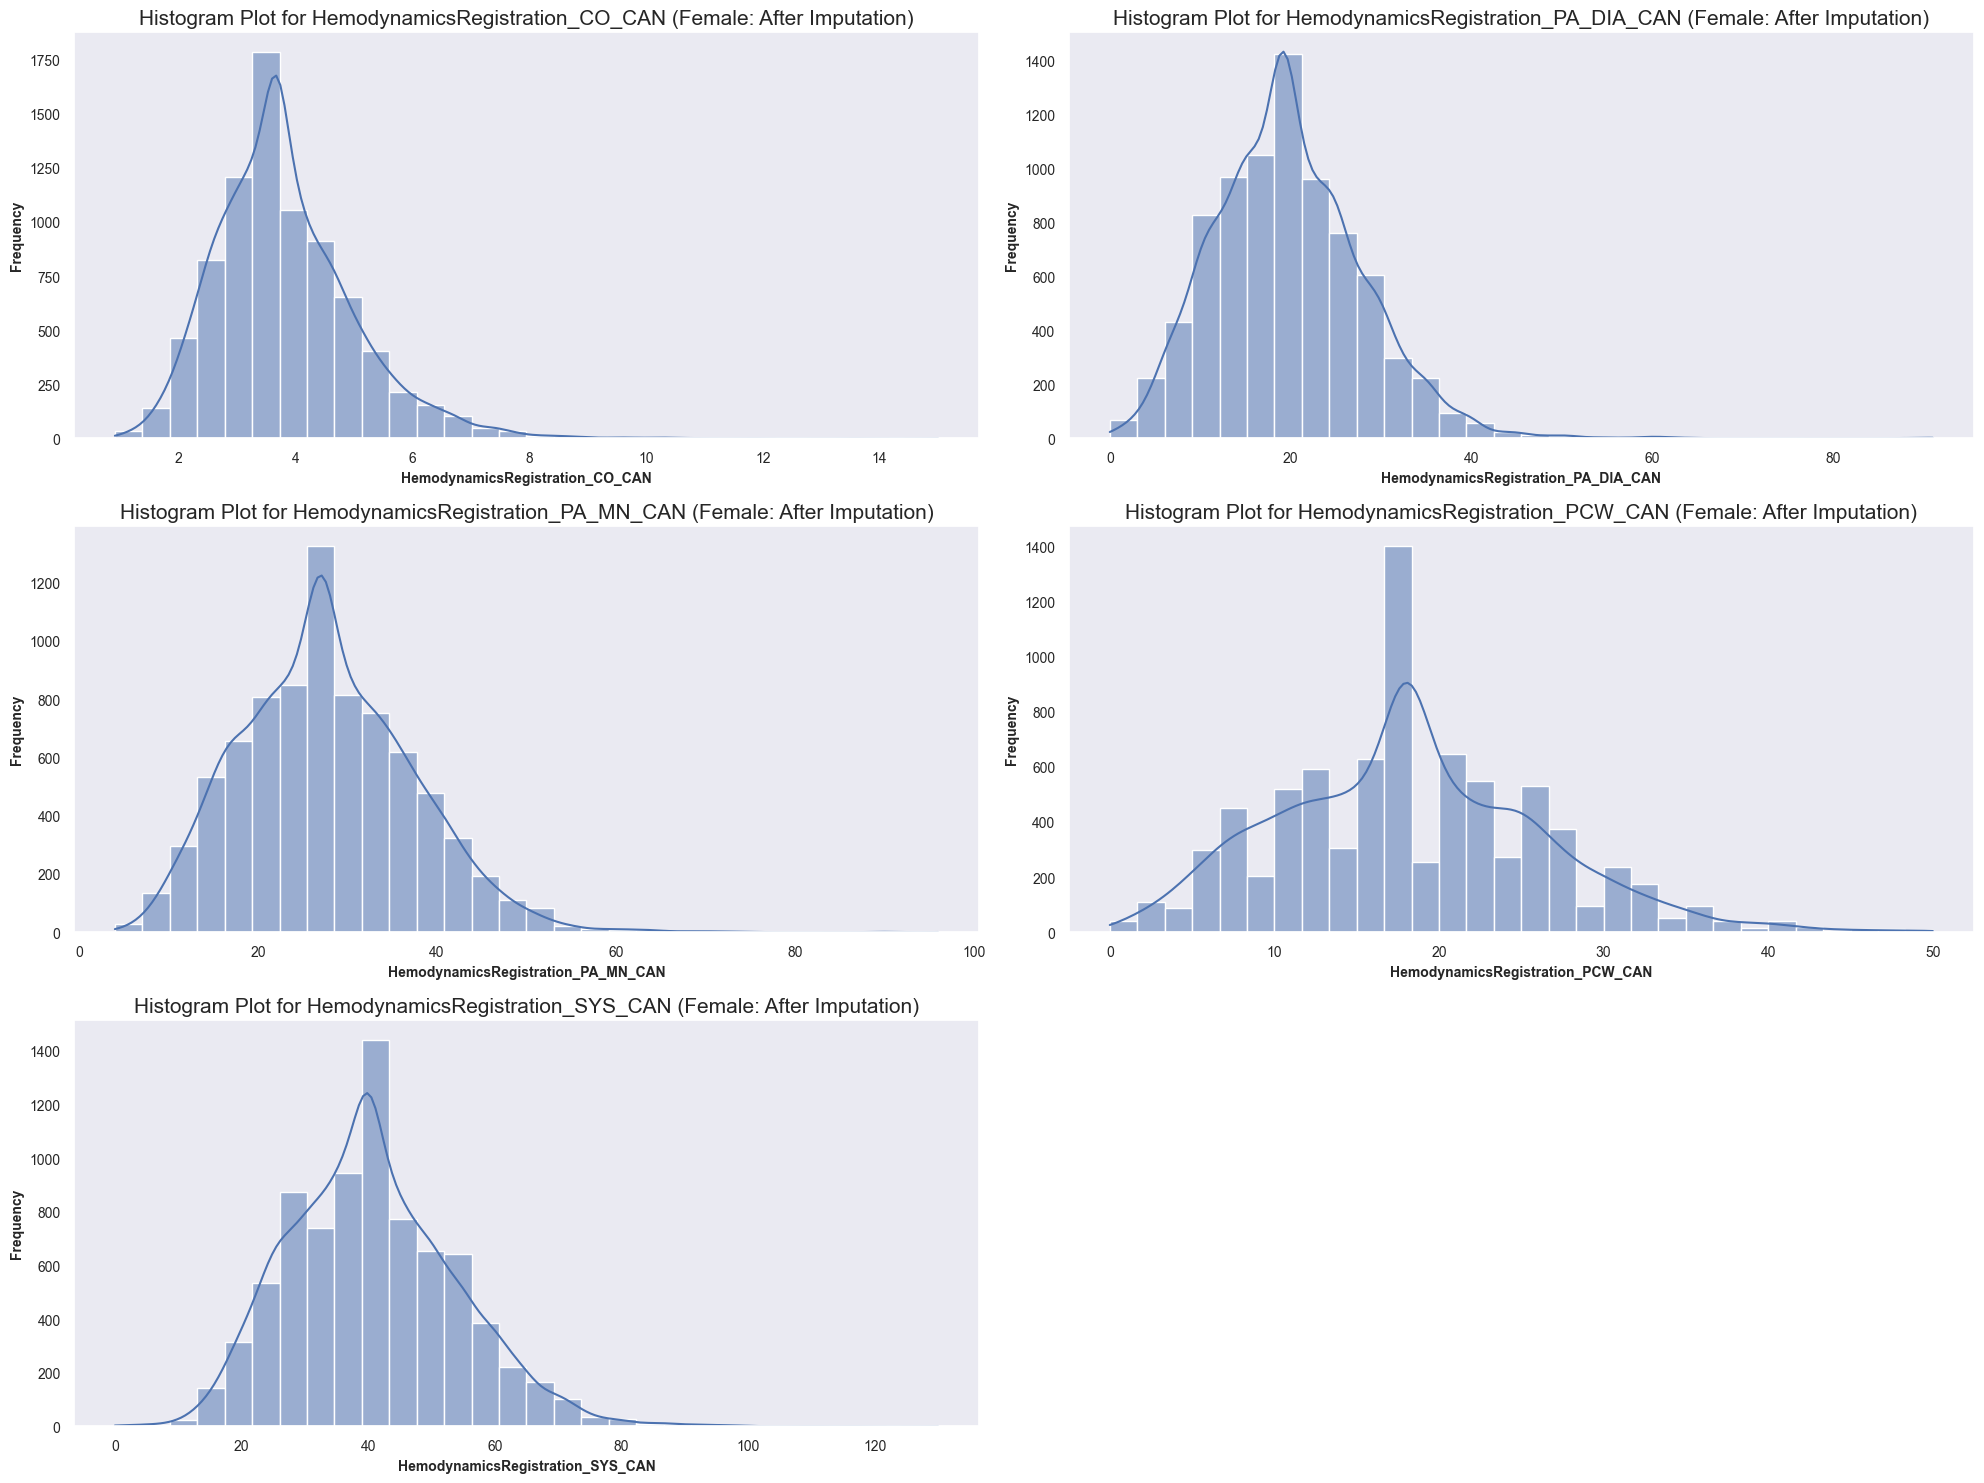

In [43]:
plot.plot_histogram(df_f, features, bins=30, txt='(Female: After Imputation)')

In [44]:
# scale for PCA
X_scaled = StandardScaler().fit_transform(df_f[features].values)

# PCA
pca = PCA(n_components=0.9, random_state=SEED).fit(X_scaled)  # 90% variance
print(f"Components: {pca.n_components_}")
print(f"Explained variance: {pca.explained_variance_ratio_}")

# Add to dataframe
pca_scores = pca.transform(X_scaled)
for i in range(pca.n_components_):
    df_f[f'PC{i+1}_hemo_registration'] = pca_scores[:, i]

# drop columns
df_f = df_f.drop(columns=features)
# shape
df_f.shape

Components: 3
Explained variance: [0.69702807 0.19138538 0.05739207]


(8064, 144)

## Hemodynamics Transplant

#### Male

In [45]:
# info
features = u.get_feature_info(df_m, 'HemodynamicsTransplant', cat=False)

                                     count       mean        std  min   25%    50%   75%    max
HemodynamicsTransplant_CO_CAN      21261.0   4.708040   1.461883  0.2   3.7   4.54   5.5   15.0
HemodynamicsTransplant_PA_DIA_CAN  21632.0  19.414557   8.583010  0.0  13.0  18.00  25.0  110.0
HemodynamicsTransplant_PA_MN_CAN   21398.0  27.341411  10.050926  0.0  20.0  26.00  34.0  110.0
HemodynamicsTransplant_PCW_CAN     20621.0  18.152328   8.812476  0.0  11.0  17.00  24.0   50.0
HemodynamicsTransplant_SYS_CAN     21650.0  40.264573  14.058181  1.0  30.0  39.00  50.0  159.0

:::: NaN Count:
HemodynamicsTransplant_CO_CAN         973
HemodynamicsTransplant_PA_DIA_CAN     602
HemodynamicsTransplant_PA_MN_CAN      836
HemodynamicsTransplant_PCW_CAN       1613
HemodynamicsTransplant_SYS_CAN        584 



In [46]:
df_m[features].corr()

,HemodynamicsTransplant_CO_CAN,HemodynamicsTransplant_PA_DIA_CAN,HemodynamicsTransplant_PA_MN_CAN,HemodynamicsTransplant_PCW_CAN,HemodynamicsTransplant_SYS_CAN
HemodynamicsTransplant_CO_CAN,1.000000,-0.242764,-0.213064,-0.245374,-0.182248
HemodynamicsTransplant_PA_DIA_CAN,-0.242764,1.000000,0.904279,0.823675,0.794811
HemodynamicsTransplant_PA_MN_CAN,-0.213064,0.904279,1.000000,0.836987,0.918455
HemodynamicsTransplant_PCW_CAN,-0.245374,0.823675,0.836987,1.000000,0.767398
HemodynamicsTransplant_SYS_CAN,-0.182248,0.794811,0.918455,0.767398,1.000000


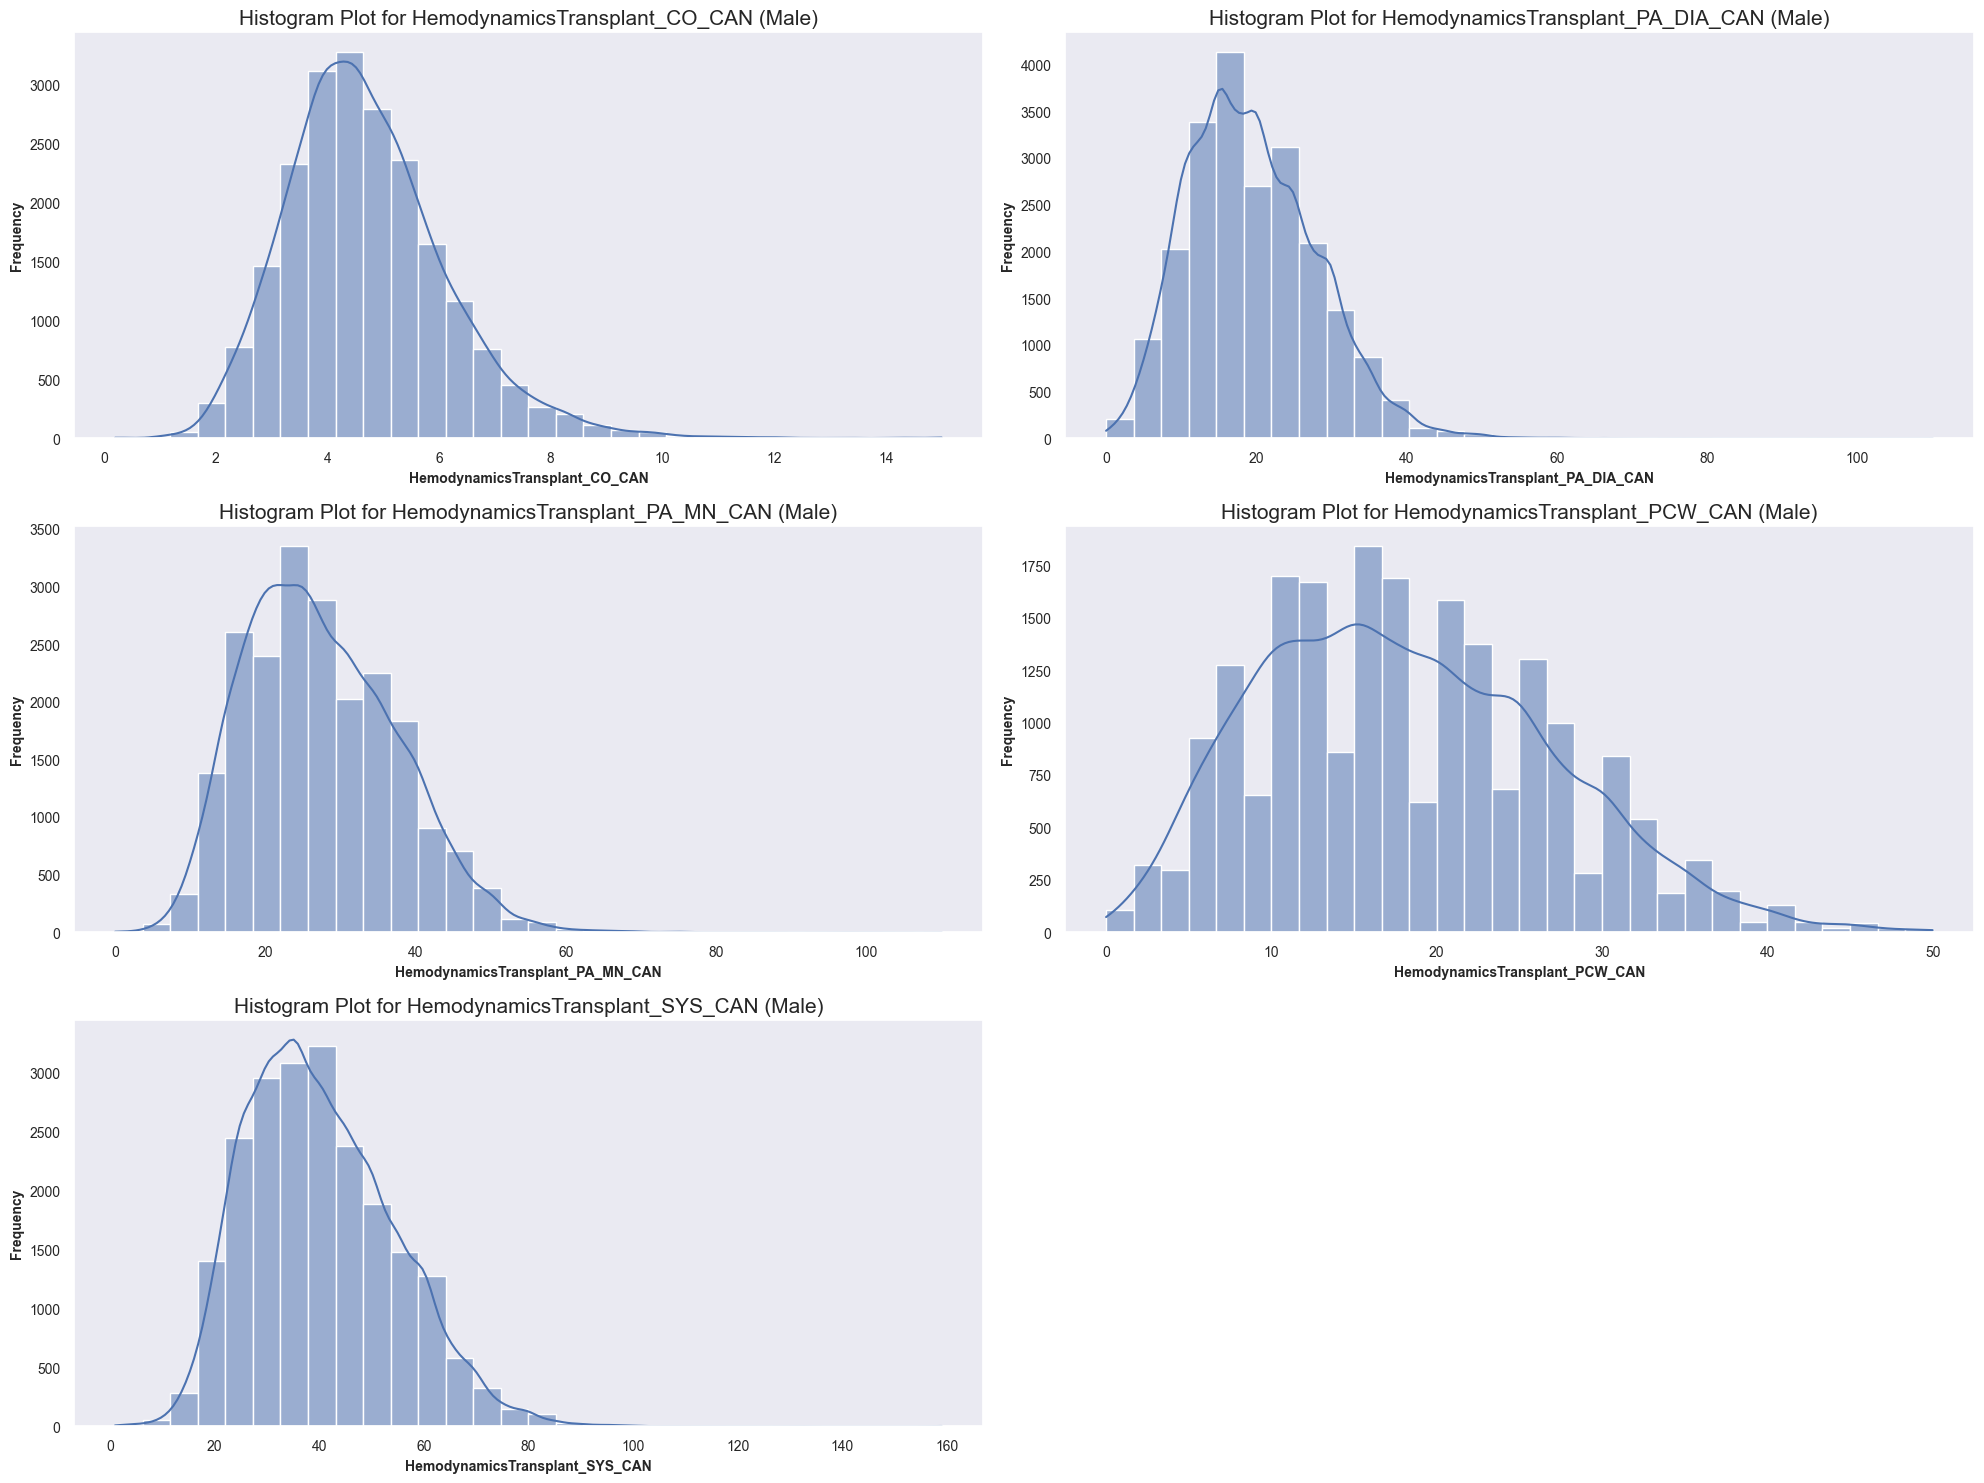

In [47]:
plot.plot_histogram(df_m, features, bins=30, txt='(Male)')

In [48]:
u.check_informative_missingness(df_m, 'HemodynamicsTransplant_CO_CAN', txt='Male')

--- Missingness (Male): HemodynamicsTransplant_CO_CAN ---
Group Sizes:    (Unknown=973, Known=21,261)
Mean survival:  (Unknown=1,279.9d, Known=1,443.7d)
Difference:     -163.8 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0001
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.1416 (Negligible)
95% CI:        [-0.2059, -0.0773]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [49]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsTransplant_CO_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsTransplant_CO_CAN ---
Pearson r=0.007, p=0.3103 & Approx. Variance Explained=0.005%
Spearman r=0.020, p=0.003801 & Approx. Variance Explained=0.039%



#### The "Shadow Variable" (Indicator) + Median Imputation

In [50]:
# impute: median and use new feature for NANS
df_m['HemodynamicsTransplant_CO_IsMissing'] = df_m['HemodynamicsTransplant_CO_CAN'].isna().astype(int)
df_m['HemodynamicsTransplant_CO_CAN'] = df_m['HemodynamicsTransplant_CO_CAN'].fillna(
    df_m['HemodynamicsTransplant_CO_CAN'].median()
)

In [51]:
u.check_informative_missingness(df_m, 'HemodynamicsTransplant_PA_DIA_CAN', txt='Male')

--- Missingness (Male): HemodynamicsTransplant_PA_DIA_CAN ---
Group Sizes:    (Unknown=602, Known=21,632)
Mean survival:  (Unknown=1,190.1d, Known=1,443.4d)
Difference:     -253.3 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0000
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.2191 (Small)
95% CI:        [-0.3001, -0.1380]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [52]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsTransplant_PA_DIA_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsTransplant_PA_DIA_CAN ---
Pearson r=-0.008, p=0.244 & Approx. Variance Explained=0.006%
Spearman r=-0.014, p=0.03893 & Approx. Variance Explained=0.020%



#### The "Shadow Variable" (Indicator) + Median Imputation

In [53]:
# impute: median and use new feature for NANS
df_m['HemodynamicsTransplant_PA_DIA_IsMissing'] = df_m['HemodynamicsTransplant_PA_DIA_CAN'].isna().astype(int)
df_m['HemodynamicsTransplant_PA_DIA_CAN'] = df_m['HemodynamicsTransplant_PA_DIA_CAN'].fillna(
    df_m['HemodynamicsTransplant_PA_DIA_CAN'].median()
)

In [54]:
u.check_informative_missingness(df_m, 'HemodynamicsTransplant_PA_MN_CAN', txt='Male')

--- Missingness (Male): HemodynamicsTransplant_PA_MN_CAN ---
Group Sizes:    (Unknown=836, Known=21,398)
Mean survival:  (Unknown=1,313.9d, Known=1,441.3d)
Difference:     -127.4 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0038
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.1102 (Negligible)
95% CI:        [-0.1793, -0.0411]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [55]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsTransplant_PA_MN_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsTransplant_PA_MN_CAN ---
Pearson r=0.006, p=0.4125 & Approx. Variance Explained=0.003%
Spearman r=-0.003, p=0.6524 & Approx. Variance Explained=0.001%



#### The "Shadow Variable" (Indicator) + Median Imputation

In [56]:
# impute: median and use new feature for NANS
df_m['HemodynamicsTransplant_PA_MN_IsMissing'] = df_m['HemodynamicsTransplant_PA_MN_CAN'].isna().astype(int)
df_m['HemodynamicsTransplant_PA_MN_CAN'] = df_m['HemodynamicsTransplant_PA_MN_CAN'].fillna(
    df_m['HemodynamicsTransplant_PA_MN_CAN'].median()
)

In [57]:
u.check_informative_missingness(df_m, 'HemodynamicsTransplant_PCW_CAN', txt='Male')

--- Missingness (Male): HemodynamicsTransplant_PCW_CAN ---
Group Sizes:    (Unknown=1,613, Known=20,621)
Mean survival:  (Unknown=1,274.6d, Known=1,449.2d)
Difference:     -174.6 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0000
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.1510 (Negligible)
95% CI:        [-0.2017, -0.1003]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [58]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsTransplant_PCW_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsTransplant_PCW_CAN ---
Pearson r=0.014, p=0.05072 & Approx. Variance Explained=0.019%
Spearman r=0.003, p=0.6805 & Approx. Variance Explained=0.001%



#### The "Shadow Variable" (Indicator) + Median Imputation

In [59]:
# impute: median and use new feature for NANS
df_m['HemodynamicsTransplant_PCW_IsMissing'] = df_m['HemodynamicsTransplant_PCW_CAN'].isna().astype(int)
df_m['HemodynamicsTransplant_PCW_CAN'] = df_m['HemodynamicsTransplant_PCW_CAN'].fillna(
    df_m['HemodynamicsTransplant_PCW_CAN'].median()
)

In [60]:
u.check_informative_missingness(df_m, 'HemodynamicsTransplant_SYS_CAN', txt='Male')

--- Missingness (Male): HemodynamicsTransplant_SYS_CAN ---
Group Sizes:    (Unknown=584, Known=21,650)
Mean survival:  (Unknown=1,170.4d, Known=1,443.7d)
Difference:     -273.3 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0000
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.2364 (Small)
95% CI:        [-0.3186, -0.1542]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [61]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsTransplant_SYS_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsTransplant_SYS_CAN ---
Pearson r=0.012, p=0.08508 & Approx. Variance Explained=0.014%
Spearman r=0.000, p=0.9805 & Approx. Variance Explained=0.000%



#### The "Shadow Variable" (Indicator) + Median Imputation

In [62]:
# impute: median and use new feature for NANS
df_m['HemodynamicsTransplant_SYS_IsMissing'] = df_m['HemodynamicsTransplant_SYS_CAN'].isna().astype(int)
df_m['HemodynamicsTransplant_SYS_CAN'] = df_m['HemodynamicsTransplant_SYS_CAN'].fillna(
    df_m['HemodynamicsTransplant_SYS_CAN'].median()
)

In [63]:
# scale for PCA
X_scaled = StandardScaler().fit_transform(df_m[features].values)

# PCA
pca = PCA(n_components=0.9, random_state=SEED).fit(X_scaled)  # 90% variance
print(f"Components: {pca.n_components_}")
print(f"Explained variance: {pca.explained_variance_ratio_}")

# Add to dataframe
pca_scores = pca.transform(X_scaled)
for i in range(pca.n_components_):
    df_m[f'PC{i+1}_hemo_transplant'] = pca_scores[:, i]

# drop columns
df_m = df_m.drop(columns=features)
# shape
df_m.shape

Components: 3
Explained variance: [0.71100219 0.18629986 0.05382423]


(22234, 149)

#### Female

In [64]:
# info
features = u.get_feature_info(df_f, 'HemodynamicsTransplant', cat=False)

                                    count       mean        std  min    25%   50%   75%    max
HemodynamicsTransplant_CO_CAN      7667.0   4.052243   1.327358  0.2   3.12   3.9   4.8   15.0
HemodynamicsTransplant_PA_DIA_CAN  7782.0  18.654562   8.203793  0.0  13.00  18.0  24.0   65.0
HemodynamicsTransplant_PA_MN_CAN   7717.0  26.460872   9.648381  0.0  19.00  26.0  33.0   88.0
HemodynamicsTransplant_PCW_CAN     7452.0  17.079301   8.375866  0.0  11.00  16.0  23.0   50.0
HemodynamicsTransplant_SYS_CAN     7788.0  38.855393  13.287188  0.0  29.00  38.0  47.0  127.0

:::: NaN Count:
HemodynamicsTransplant_CO_CAN        397
HemodynamicsTransplant_PA_DIA_CAN    282
HemodynamicsTransplant_PA_MN_CAN     347
HemodynamicsTransplant_PCW_CAN       612
HemodynamicsTransplant_SYS_CAN       276 



In [65]:
df_f[features].corr()

,HemodynamicsTransplant_CO_CAN,HemodynamicsTransplant_PA_DIA_CAN,HemodynamicsTransplant_PA_MN_CAN,HemodynamicsTransplant_PCW_CAN,HemodynamicsTransplant_SYS_CAN
HemodynamicsTransplant_CO_CAN,1.000000,-0.210790,-0.177840,-0.231536,-0.142130
HemodynamicsTransplant_PA_DIA_CAN,-0.210790,1.000000,0.890623,0.810877,0.777492
HemodynamicsTransplant_PA_MN_CAN,-0.177840,0.890623,1.000000,0.824702,0.912752
HemodynamicsTransplant_PCW_CAN,-0.231536,0.810877,0.824702,1.000000,0.746656
HemodynamicsTransplant_SYS_CAN,-0.142130,0.777492,0.912752,0.746656,1.000000


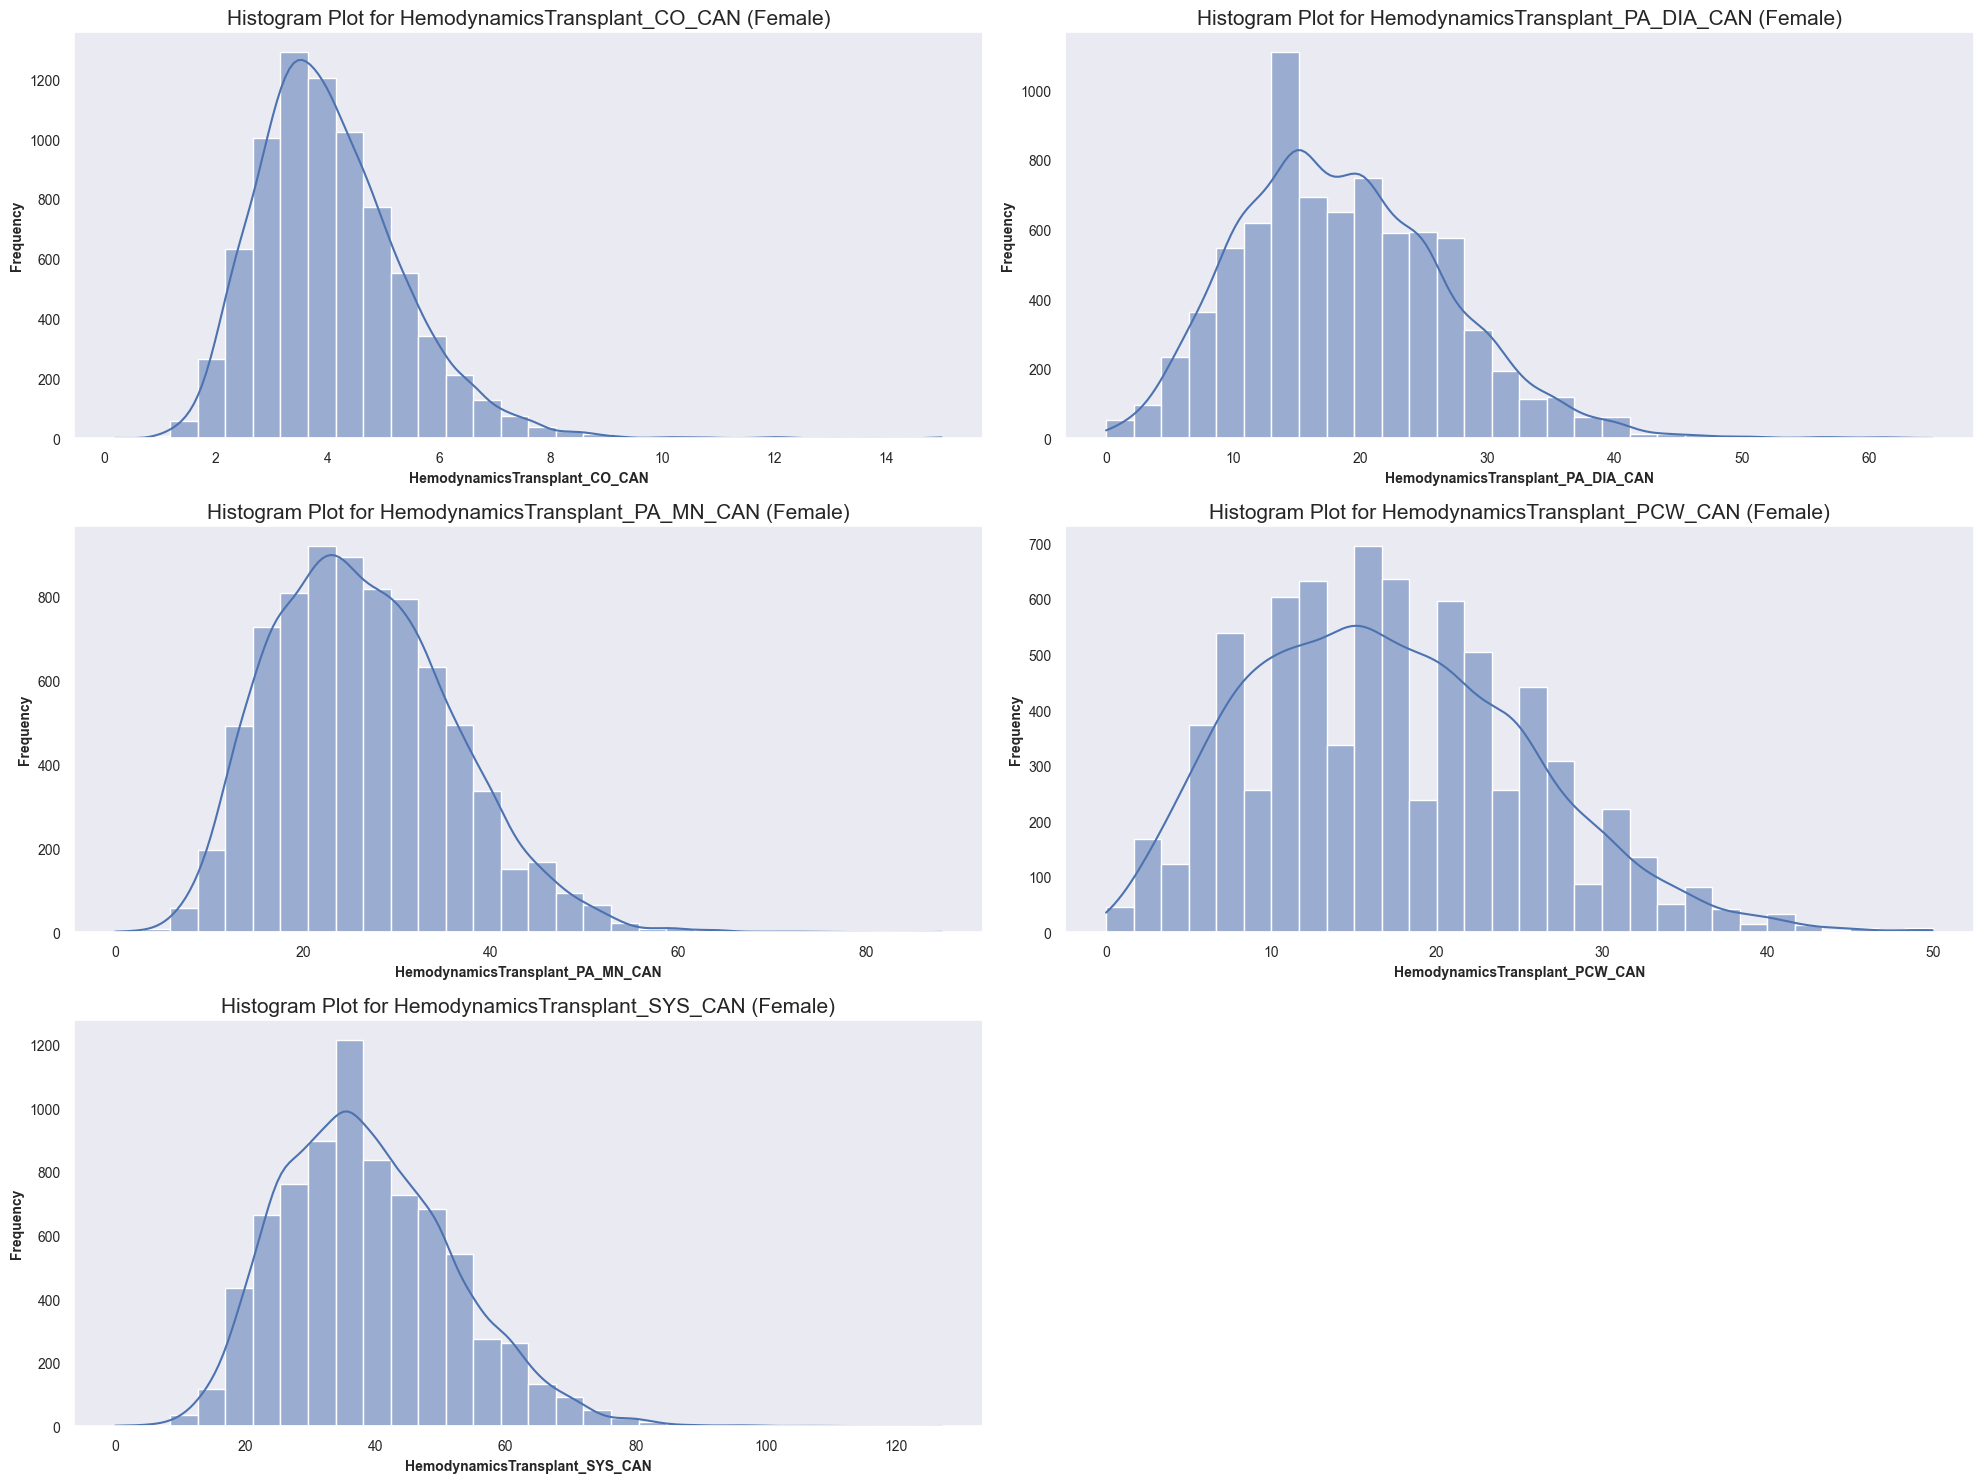

In [66]:
plot.plot_histogram(df_f, features, bins=30, txt='(Female)')

In [67]:
u.check_informative_missingness(df_f, 'HemodynamicsTransplant_CO_CAN', txt='Female')

--- Missingness (Female): HemodynamicsTransplant_CO_CAN ---
Group Sizes:    (Unknown=397, Known=7,667)
Mean survival:  (Unknown=1,384.8d, Known=1,426.2d)
Difference:     -41.5 days

--- Welch's t-test Analysis ---
ρ-Value: 0.5181
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.0360 (Negligible)
95% CI:        [-0.1368, 0.0649]
Result: Likely Random Missingness (Effect size not significant)



In [68]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsTransplant_CO_CAN', txt='Female')

--- Value Predicts Survival (Female): HemodynamicsTransplant_CO_CAN ---
Pearson r=-0.023, p=0.04261 & Approx. Variance Explained=0.054%
Spearman r=-0.018, p=0.1207 & Approx. Variance Explained=0.031%



#### Median Imputation

In [69]:
# Median impute
df_f['HemodynamicsTransplant_CO_CAN'] = df_f['HemodynamicsTransplant_CO_CAN'].fillna(
    df_f['HemodynamicsTransplant_CO_CAN'].median()
)

In [70]:
u.check_informative_missingness(df_f, 'HemodynamicsTransplant_PA_DIA_CAN', txt='Female')

--- Missingness (Female): HemodynamicsTransplant_PA_DIA_CAN ---
Group Sizes:    (Unknown=282, Known=7,782)
Mean survival:  (Unknown=1,385.3d, Known=1,425.6d)
Difference:     -40.3 days

--- Welch's t-test Analysis ---
ρ-Value: 0.6060
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.0350 (Negligible)
95% CI:        [-0.1538, 0.0839]
Result: Likely Random Missingness (Effect size not significant)



In [71]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsTransplant_PA_DIA_CAN', txt='Female')

--- Value Predicts Survival (Female): HemodynamicsTransplant_PA_DIA_CAN ---
Pearson r=0.014, p=0.2166 & Approx. Variance Explained=0.020%
Spearman r=0.002, p=0.8645 & Approx. Variance Explained=0.000%



#### Median Imputation

In [72]:
# Median impute
df_f['HemodynamicsTransplant_PA_DIA_CAN'] = df_f['HemodynamicsTransplant_PA_DIA_CAN'].fillna(
    df_f['HemodynamicsTransplant_PA_DIA_CAN'].median()
)

In [73]:
u.check_informative_missingness(df_f, 'HemodynamicsTransplant_PA_MN_CAN', txt='Female')

--- Missingness (Female): HemodynamicsTransplant_PA_MN_CAN ---
Group Sizes:    (Unknown=347, Known=7,717)
Mean survival:  (Unknown=1,421.0d, Known=1,424.3d)
Difference:     -3.3 days

--- Welch's t-test Analysis ---
ρ-Value: 0.9630
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.0029 (Negligible)
95% CI:        [-0.1104, 0.1047]
Result: Likely Random Missingness (Effect size not significant)



In [74]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsTransplant_PA_MN_CAN', txt='Female')

--- Value Predicts Survival (Female): HemodynamicsTransplant_PA_MN_CAN ---
Pearson r=0.030, p=0.007741 & Approx. Variance Explained=0.092%
Spearman r=0.016, p=0.149 & Approx. Variance Explained=0.027%



#### Median Imputation

In [75]:
# Median impute
df_f['HemodynamicsTransplant_PA_MN_CAN'] = df_f['HemodynamicsTransplant_PA_MN_CAN'].fillna(
    df_f['HemodynamicsTransplant_PA_MN_CAN'].median()
)

In [76]:
u.check_informative_missingness(df_f, 'HemodynamicsTransplant_PCW_CAN', txt='Female')

--- Missingness (Female): HemodynamicsTransplant_PCW_CAN ---
Group Sizes:    (Unknown=612, Known=7,452)
Mean survival:  (Unknown=1,360.9d, Known=1,429.4d)
Difference:     -68.5 days

--- Welch's t-test Analysis ---
ρ-Value: 0.1840
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.0594 (Negligible)
95% CI:        [-0.1418, 0.0230]
Result: Likely Random Missingness (Effect size not significant)



In [77]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsTransplant_PCW_CAN', txt='Female')

--- Value Predicts Survival (Female): HemodynamicsTransplant_PCW_CAN ---
Pearson r=0.021, p=0.06621 & Approx. Variance Explained=0.045%
Spearman r=0.014, p=0.2341 & Approx. Variance Explained=0.019%



#### The "Shadow Variable" (Indicator) + Median Imputation

In [78]:
# impute: median and use new feature for NANS
df_f['HemodynamicsTransplant_PCW_IsMissing'] = df_f['HemodynamicsTransplant_PCW_CAN'].isna().astype(int)
df_f['HemodynamicsTransplant_PCW_CAN'] = df_f['HemodynamicsTransplant_PCW_CAN'].fillna(
    df_f['HemodynamicsTransplant_PCW_CAN'].median()
)

In [79]:
u.check_informative_missingness(df_f, 'HemodynamicsTransplant_SYS_CAN', txt='Female')

--- Missingness (Female): HemodynamicsTransplant_SYS_CAN ---
Group Sizes:    (Unknown=276, Known=7,788)
Mean survival:  (Unknown=1,376.3d, Known=1,425.9d)
Difference:     -49.6 days

--- Welch's t-test Analysis ---
ρ-Value: 0.5305
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.0430 (Negligible)
95% CI:        [-0.1630, 0.0771]
Result: Likely Random Missingness (Effect size not significant)



In [80]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsTransplant_SYS_CAN', txt='Female')

--- Value Predicts Survival (Female): HemodynamicsTransplant_SYS_CAN ---
Pearson r=0.032, p=0.004877 & Approx. Variance Explained=0.102%
Spearman r=0.019, p=0.09481 & Approx. Variance Explained=0.036%



#### Median Imputation

In [81]:
# Median impute
df_f['HemodynamicsTransplant_SYS_CAN'] = df_f['HemodynamicsTransplant_SYS_CAN'].fillna(
    df_f['HemodynamicsTransplant_SYS_CAN'].median()
)

In [82]:
# scale for PCA
X_scaled = StandardScaler().fit_transform(df_f[features].values)

# PCA
pca = PCA(n_components=0.9, random_state=SEED).fit(X_scaled)  # 90% variance
print(f"Components: {pca.n_components_}")
print(f"Explained variance: {pca.explained_variance_ratio_}")

# Add to dataframe
pca_scores = pca.transform(X_scaled)
for i in range(pca.n_components_):
    df_f[f'PC{i+1}_hemo_transplant'] = pca_scores[:, i]

# drop columns
df_f = df_f.drop(columns=features)
# shape
df_f.shape

Components: 3
Explained variance: [0.7003507  0.19045857 0.0572182 ]


(8064, 143)

## Functional Status Registration

#### Male

In [83]:
# info
features = u.get_feature_info(df_m, 'FunctionalStatusRegistration', cat=False)

                                  count unique top  freq
FunctionalStatusRegistration_CAN  21528     10  20  5035

:::: NaN Count:
FunctionalStatusRegistration_CAN    706 



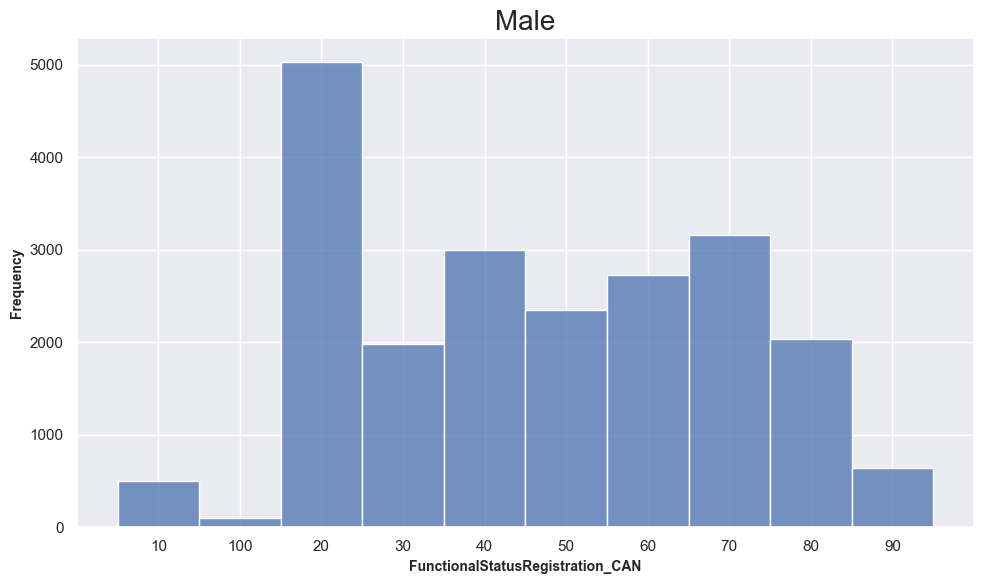

In [84]:
plot_histogram(df_m, 'FunctionalStatusRegistration_CAN', bins=30, txt='Male', KDE=False)

In [85]:
u.check_informative_missingness(df_m, 'FunctionalStatusRegistration_CAN', txt='Male')

--- Missingness (Male): FunctionalStatusRegistration_CAN ---
Group Sizes:    (Unknown=706, Known=21,528)
Mean survival:  (Unknown=1,174.2d, Known=1,445.1d)
Difference:     -270.9 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0000
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.2343 (Small)
95% CI:        [-0.3093, -0.1593]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



#### The "Shadow Variable" (Indicator) + Mode Imputation

In [86]:
# impute: median and use new feature for NANS
df_m['FunctionalStatusRegistration_IsMissing'] = df_m ['FunctionalStatusRegistration_CAN'].isna().astype(int)
df_m['FunctionalStatusRegistration_CAN'] = df_m['FunctionalStatusRegistration_CAN'].fillna(
    df_m['FunctionalStatusRegistration_CAN'].mode()
)
# change datatype
df_m['FunctionalStatusRegistration_CAN'] = df_m['FunctionalStatusRegistration_CAN'].astype('category')
# sanity check
df_m.FunctionalStatusRegistration_IsMissing.sum()

np.int64(706)

#### Female

In [87]:
# info
features = u.get_feature_info(df_f, 'FunctionalStatusRegistration', cat=False)

                                 count unique top  freq
FunctionalStatusRegistration_CAN  7797     10  20  1766

:::: NaN Count:
FunctionalStatusRegistration_CAN    267 



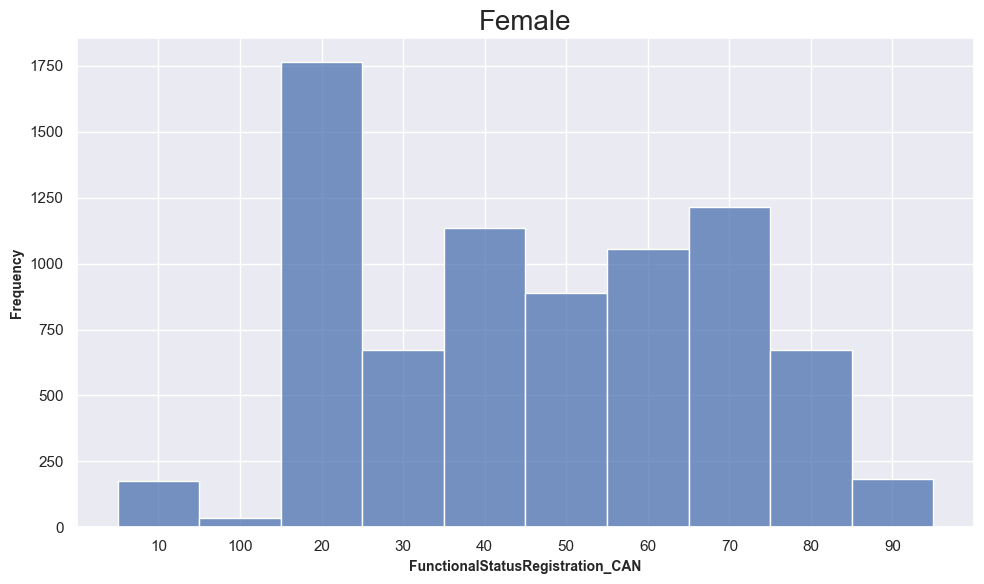

In [88]:
plot_histogram(df_f, 'FunctionalStatusRegistration_CAN', bins=30, txt='Female', KDE=False)

In [89]:
u.check_informative_missingness(df_f, features[0], txt='Female')

--- Missingness (Female): FunctionalStatusRegistration_CAN ---
Group Sizes:    (Unknown=267, Known=7,797)
Mean survival:  (Unknown=1,212.7d, Known=1,431.4d)
Difference:     -218.7 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0013
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.1897 (Negligible)
95% CI:        [-0.3117, -0.0677]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



#### The "Shadow Variable" (Indicator) + Mode Imputation

In [90]:
# impute: median and use new feature for NANS
df_f['FunctionalStatusRegistration_IsMissing'] = df_f[features[0]].isna().astype(int)
df_f[features[0]] = df_f[features[0]].fillna(df_f[features[0]].mode()[0])
# change datatype
df_f[features[0]] = df_f[features[0]].astype('category')
# sanity check
df_f.FunctionalStatusRegistration_IsMissing.sum()

np.int64(267)

## Functional Status Transplant

#### Male

In [91]:
# info
features = u.get_feature_info(df_m, 'FunctionalStatusTransplant', cat=False)

                                count unique top  freq
FunctionalStatusTransplant_CAN  21252     10  20  6347

:::: NaN Count:
FunctionalStatusTransplant_CAN    982 



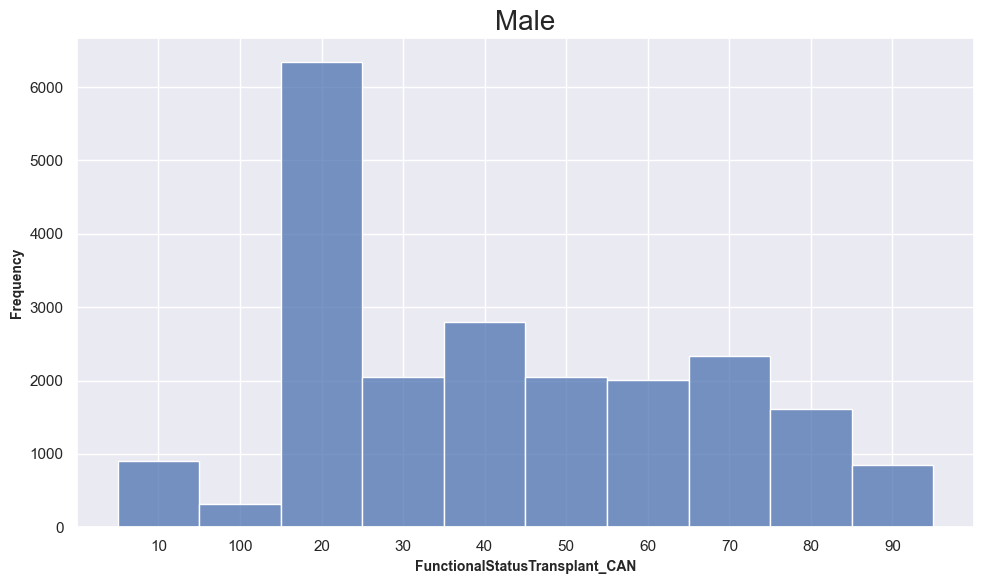

In [92]:
plot_histogram(df_m, features[0], bins=30, txt='Male', KDE=False)

In [93]:
u.check_informative_missingness(df_m, features[0], txt='Male')

--- Missingness (Male): FunctionalStatusTransplant_CAN ---
Group Sizes:    (Unknown=982, Known=21,252)
Mean survival:  (Unknown=1,125.1d, Known=1,450.9d)
Difference:     -325.8 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0000
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.2821 (Small)
95% CI:        [-0.3462, -0.2181]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



#### The "Shadow Variable" (Indicator) + Mode Imputation

In [94]:
# impute: mode and use new feature for NANS
df_m['FunctionalStatusTransplant_IsMissing'] = df_m[features[0]].isna().astype(int)
df_m[features[0]] = df_m[features[0]].fillna(df_m[features[0]].mode()[0])
# change datatype
df_m[features[0]] = df_m[features[0]].astype('category')
# sanity check
df_m.FunctionalStatusTransplant_IsMissing.sum()

np.int64(982)

In [95]:
df_m[['FunctionalStatusRegistration_CAN', 'FunctionalStatusTransplant_CAN']].corr()

,FunctionalStatusRegistration_CAN,FunctionalStatusTransplant_CAN
FunctionalStatusRegistration_CAN,1.000000,0.470351
FunctionalStatusTransplant_CAN,0.470351,1.000000


#### Female

In [96]:
# info
features = u.get_feature_info(df_f, 'FunctionalStatusTransplant', cat=False)

                               count unique top  freq
FunctionalStatusTransplant_CAN  7672     10  20  2264

:::: NaN Count:
FunctionalStatusTransplant_CAN    392 



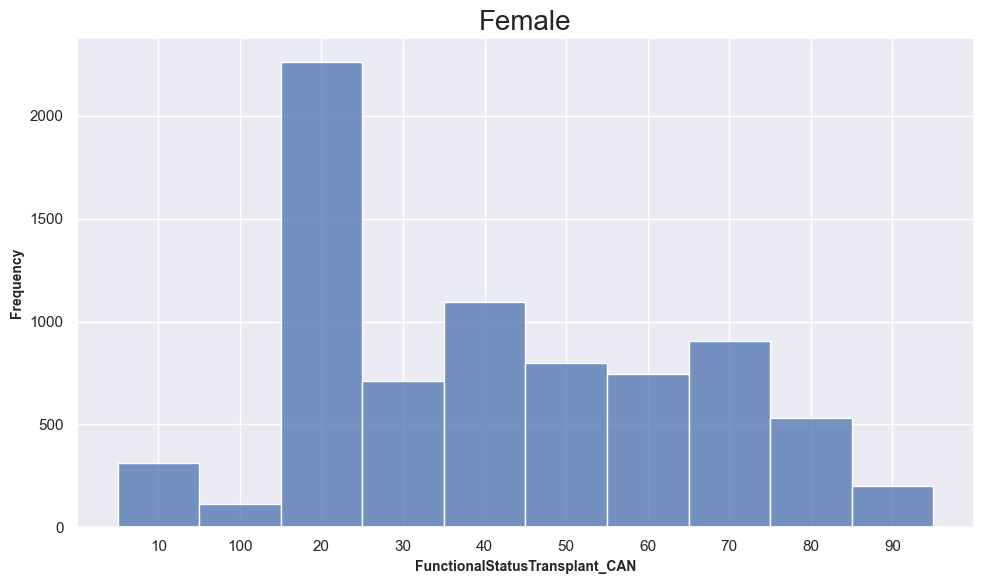

In [97]:
plot_histogram(df_f, features[0], bins=30, txt='Female', KDE=False)

In [98]:
u.check_informative_missingness(df_f, features[0], txt='Female')

--- Missingness (Female): FunctionalStatusTransplant_CAN ---
Group Sizes:    (Unknown=392, Known=7,672)
Mean survival:  (Unknown=1,139.9d, Known=1,438.7d)
Difference:     -298.8 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0000
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.2595 (Small)
95% CI:        [-0.3610, -0.1579]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



#### The "Shadow Variable" (Indicator) + Mode Imputation

In [99]:
# impute: mode and use new feature for NANS
df_f['FunctionalStatusTransplant_IsMissing'] = df_f[features[0]].isna().astype(int)
df_f[features[0]] = df_f[features[0]].fillna(df_f[features[0]].mode()[0])
# change datatype
df_f[features[0]] = df_f[features[0]].astype('category')
# sanity check
df_f.FunctionalStatusTransplant_IsMissing.sum()

np.int64(392)

In [100]:
df_f[['FunctionalStatusRegistration_CAN', 'FunctionalStatusTransplant_CAN']].corr()

,FunctionalStatusRegistration_CAN,FunctionalStatusTransplant_CAN
FunctionalStatusRegistration_CAN,1.000000,0.497816
FunctionalStatusTransplant_CAN,0.497816,1.000000


## Creatinine Registration
#### [Creatinine](https://johnshopkinshealthcare.staywellsolutionsonline.com/BreatheEasy/167,creatinine_serum)
* Creatinine is a waste product that forms when creatine, a substance found in your muscles, breaks down. It's usually filtered out of the blood by the kidneys and excreted in urine. Measuring creatinine levels in the blood can help assess kidney function.
    * Normal
        * 0.7 to 1.3 mg/dL for adult males
        * 0.5 to 1.1 mg/dL for adult females
* High creatinine indicates elevated levels of a waste product in the blood, primarily signaling that the kidneys are not filtering efficiently, commonly termed renal dysfunction, impaired kidney function, or kidney damage.

#### Male

In [101]:
# info
features = u.get_feature_info(df_m, 'CreatinineRegistration_CAN', cat=False)

                              count      mean       std   min  25%   50%   75%   max
CreatinineRegistration_CAN  22151.0  1.425444  0.969521  0.08  1.0  1.22  1.54  24.0

:::: NaN Count:
CreatinineRegistration_CAN    83 



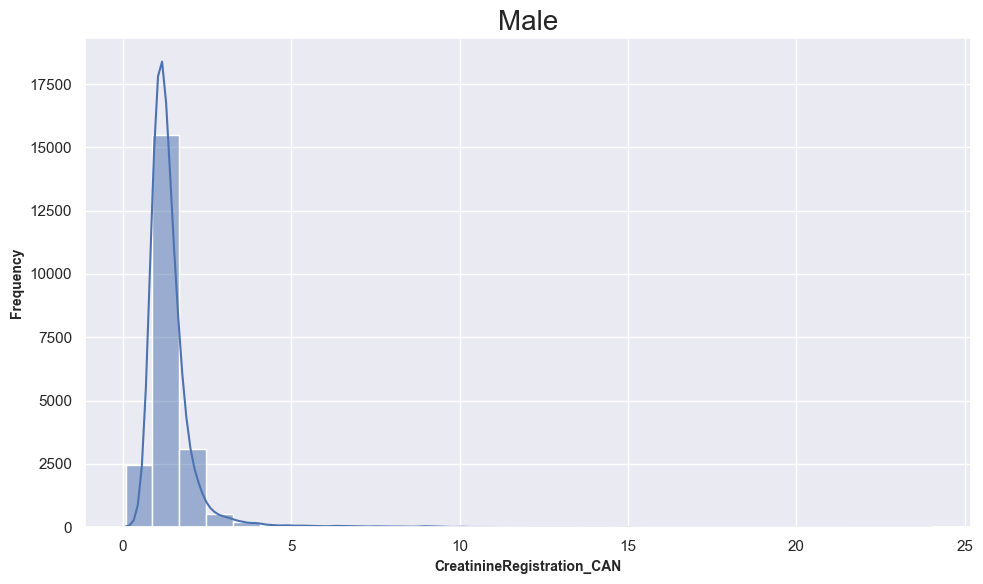

In [102]:
plot_histogram(df_m, 'CreatinineRegistration_CAN', bins=30, txt='Male')

In [103]:
u.check_informative_missingness(df_m, 'CreatinineRegistration_CAN', txt='Male')

--- Missingness (Male): CreatinineRegistration_CAN ---
Group Sizes:    (Unknown=83, Known=22,151)
Mean survival:  (Unknown=1,209.8d, Known=1,437.4d)
Difference:     -227.5 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0999
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.1967 (Negligible)
95% CI:        [-0.4122, 0.0188]
Result: Likely Random Missingness (Effect size not significant)



In [104]:
u.continuous_value_predicts_survival(df_m, 'CreatinineRegistration_CAN', txt='Male')

--- Value Predicts Survival (Male): CreatinineRegistration_CAN ---
Pearson r=-0.047, p=2.389e-12 & Approx. Variance Explained=0.222%
Spearman r=-0.060, p=5.589e-19 & Approx. Variance Explained=0.357%



#### Female

In [105]:
features = u.get_feature_info(df_f, 'CreatinineRegistration_CAN', cat=False)

                             count      mean       std   min  25%  50%  75%   max
CreatinineRegistration_CAN  8044.0  1.184423  0.880839  0.19  0.8  1.0  1.3  21.0

:::: NaN Count:
CreatinineRegistration_CAN    20 



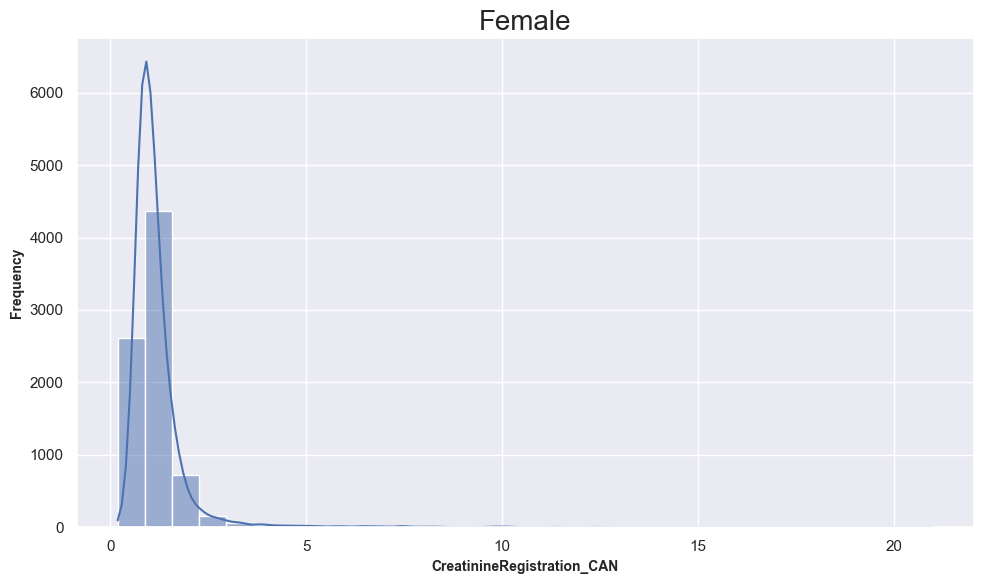

In [106]:
plot_histogram(df_f, 'CreatinineRegistration_CAN', bins=30, txt='Female')

In [107]:
u.check_informative_missingness(df_f, 'CreatinineRegistration_CAN', txt='Female')

--- Missingness (Female): CreatinineRegistration_CAN ---
Group Sizes:    (Unknown=20, Known=8,044)
Mean survival:  (Unknown=1,713.4d, Known=1,423.5d)
Difference:     289.9 days

--- Welch's t-test Analysis ---
ρ-Value: 0.3218
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     0.2514 (Small)
95% CI:        [-0.1874, 0.6902]
Result: Likely Random Missingness (Effect size not significant)



In [108]:
u.continuous_value_predicts_survival(df_f, 'CreatinineRegistration_CAN', txt='Female')

--- Value Predicts Survival (Female): CreatinineRegistration_CAN ---
Pearson r=-0.054, p=1.46e-06 & Approx. Variance Explained=0.288%
Spearman r=-0.043, p=9.94e-05 & Approx. Variance Explained=0.188%



#### Log Transform

In [109]:
# Log Transform
df_m['CreatinineRegistration_Log'] = np.log1p(df_m.CreatinineRegistration_CAN)
# female
df_f['CreatinineRegistration_Log'] = np.log1p(df_f.CreatinineRegistration_CAN)
# remove
df_m = df_m.drop('CreatinineRegistration_CAN', axis=1)
df_f = df_f.drop('CreatinineRegistration_CAN', axis=1)

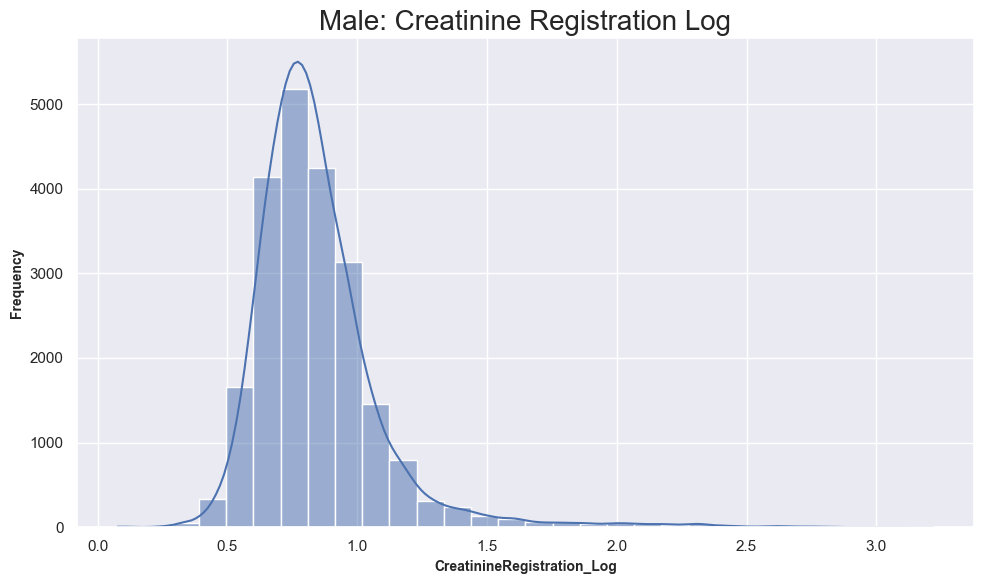

In [110]:
plot_histogram(df_m, 'CreatinineRegistration_Log', txt='Male: Creatinine Registration Log', bins=30)

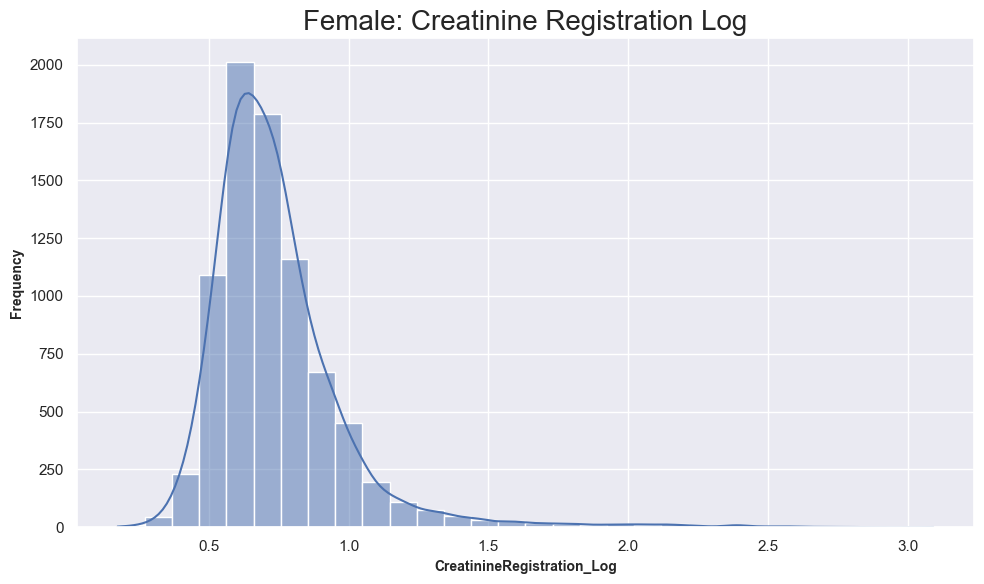

In [111]:
plot_histogram(df_f, 'CreatinineRegistration_Log', txt='Female: Creatinine Registration Log', bins=30)

#### The "Shadow Variable" (Indicator) + Median Imputation

In [112]:
# impute: median and use new feature for NANS
df_m['CreatinineRegistration_Log_IsMissing'] = df_m.CreatinineRegistration_Log.isna().astype(int)
# female
df_f['CreatinineRegistration_Log_IsMissing'] = df_f.CreatinineRegistration_Log.isna().astype(int)
# median
df_m['CreatinineRegistration_Log'] = df_m.CreatinineRegistration_Log.fillna(df_m.CreatinineRegistration_Log.median())
# female
df_f['CreatinineRegistration_Log'] = df_f.CreatinineRegistration_Log.fillna(df_f.CreatinineRegistration_Log.median())
# sanity check
df_m['CreatinineRegistration_Log_IsMissing'].sum(), df_f['CreatinineRegistration_Log_IsMissing'].sum()

(np.int64(83), np.int64(20))

## Creatinine Transplant

#### Male

In [113]:
# info
features = u.get_feature_info(df_m, 'CreatinineTransplant_CAN', cat=False)

                            count      mean      std   min  25%   50%   75%   max
CreatinineTransplant_CAN  22193.0  1.433014  0.99165  0.06  1.0  1.24  1.57  37.0

:::: NaN Count:
CreatinineTransplant_CAN    41 



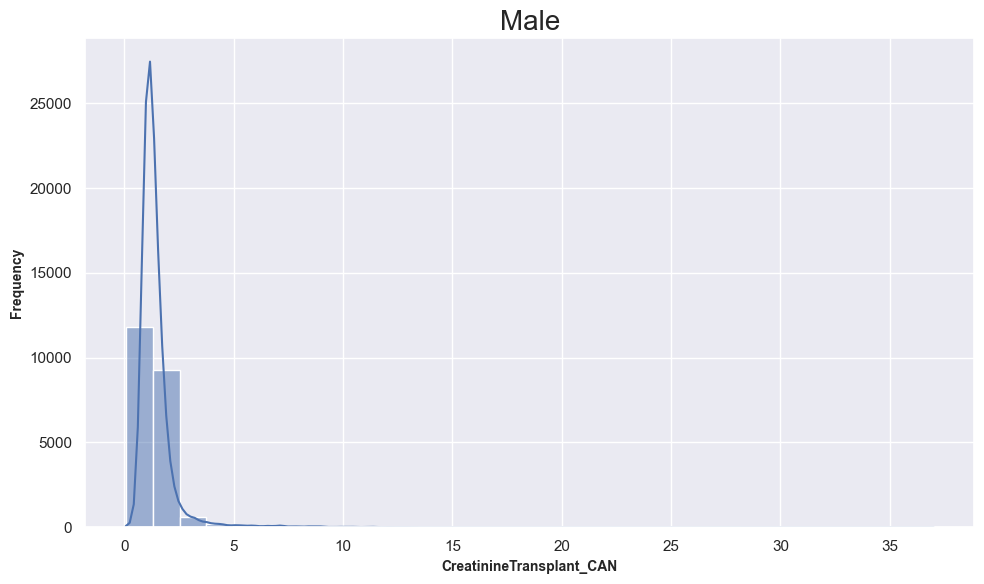

In [114]:
plot_histogram(df_m, 'CreatinineTransplant_CAN', bins=30, txt='Male')

In [115]:
u.check_informative_missingness(df_m, 'CreatinineTransplant_CAN', txt='Male')

--- Missingness (Male): CreatinineTransplant_CAN ---
Group Sizes:    (Unknown=41, Known=22,193)
Mean survival:  (Unknown=174.6d, Known=1,438.8d)
Difference:     -1,264.3 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0000
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -1.0941 (Large)
95% CI:        [-1.4006, -0.7875]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [116]:
u.continuous_value_predicts_survival(df_m, 'CreatinineTransplant_CAN', txt='Female')

--- Value Predicts Survival (Female): CreatinineTransplant_CAN ---
Pearson r=-0.037, p=4.137e-08 & Approx. Variance Explained=0.135%
Spearman r=-0.041, p=8.324e-10 & Approx. Variance Explained=0.170%



#### Female

In [117]:
# info
features = u.get_feature_info(df_f, 'CreatinineTransplant_CAN', cat=False)

                           count      mean       std   min  25%  50%  75%   max
CreatinineTransplant_CAN  8050.0  1.197711  0.979887  0.13  0.8  1.0  1.3  24.0

:::: NaN Count:
CreatinineTransplant_CAN    14 



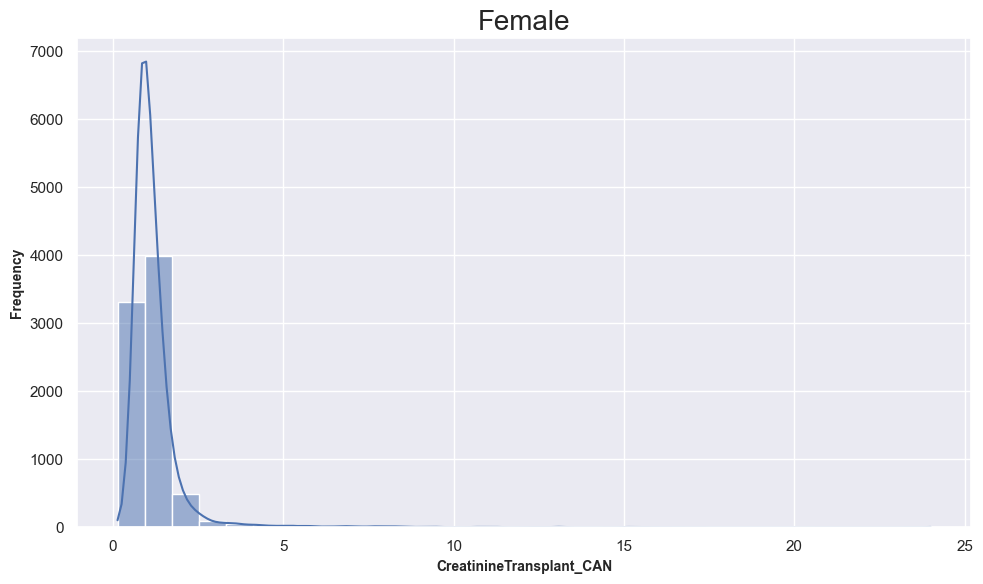

In [118]:
plot_histogram(df_f, 'CreatinineTransplant_CAN', bins=30, txt='Female')

In [119]:
u.check_informative_missingness(df_f, 'CreatinineTransplant_CAN', txt='Female')

--- Missingness (Female): CreatinineTransplant_CAN ---
Group Sizes:    (Unknown=14, Known=8,050)
Mean survival:  (Unknown=303.6d, Known=1,426.1d)
Difference:     -1,122.5 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0000
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.9740 (Large)
95% CI:        [-1.4984, -0.4495]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [120]:
u.continuous_value_predicts_survival(df_f, 'CreatinineTransplant_CAN', txt='Female')

--- Value Predicts Survival (Female): CreatinineTransplant_CAN ---
Pearson r=-0.052, p=3.632e-06 & Approx. Variance Explained=0.266%
Spearman r=-0.036, p=0.001291 & Approx. Variance Explained=0.129%



#### Log Transform

In [121]:
# Log Transform
df_m['CreatinineTransplant_Log'] = np.log1p(df_m.CreatinineTransplant_CAN)
# female
df_f['CreatinineTransplant_Log'] = np.log1p(df_f.CreatinineTransplant_CAN)
# remove
df_m = df_m.drop('CreatinineTransplant_CAN', axis=1)
df_f = df_f.drop('CreatinineTransplant_CAN', axis=1)

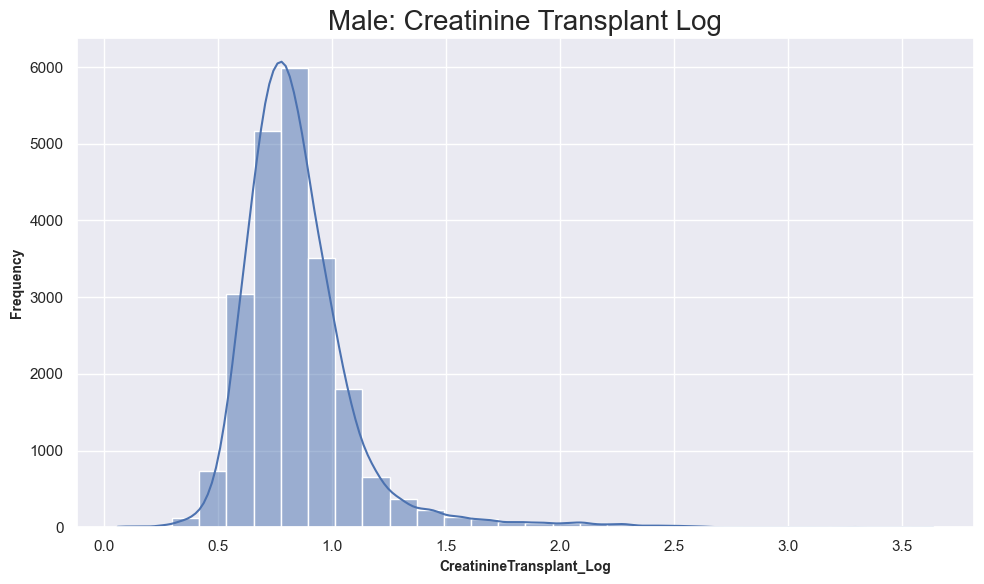

In [122]:
plot_histogram(df_m, 'CreatinineTransplant_Log', txt='Male: Creatinine Transplant Log', bins=30)

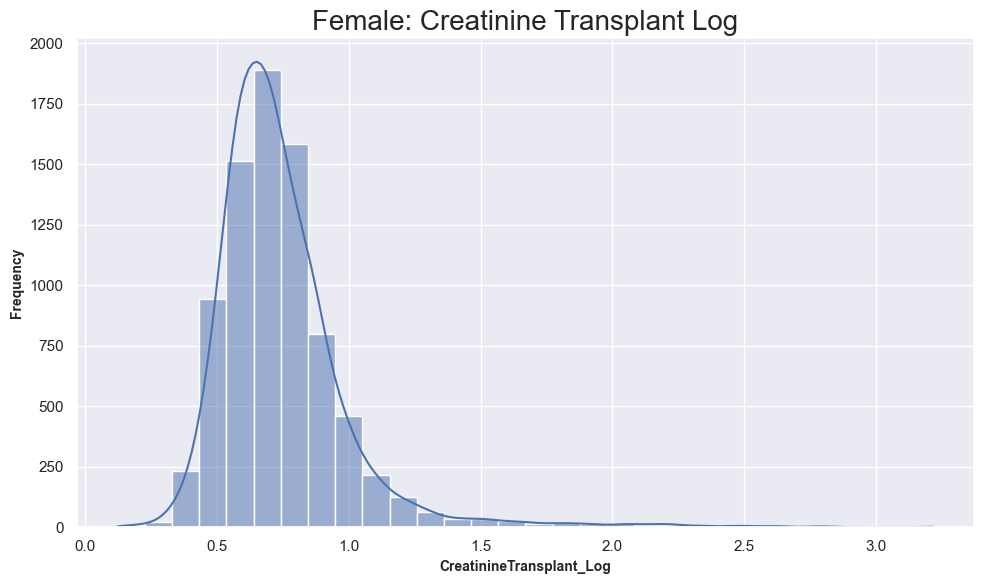

In [123]:
plot_histogram(df_f, 'CreatinineTransplant_Log', txt='Female: Creatinine Transplant Log', bins=30)

#### The "Shadow Variable" (Indicator) + Median Imputation

In [124]:
# impute: median and use new feature for NANS
df_m['CreatinineTransplant_Log_IsMissing'] = df_m.CreatinineTransplant_Log.isna().astype(int)
# female
df_f['CreatinineTransplant_Log_IsMissing'] = df_f.CreatinineTransplant_Log.isna().astype(int)
# median
df_m['CreatinineTransplant_Log'] = df_m.CreatinineTransplant_Log.fillna(df_m.CreatinineTransplant_Log.median())
# female
df_f['CreatinineTransplant_Log'] = df_f.CreatinineTransplant_Log.fillna(df_f.CreatinineTransplant_Log.median())
# sanity check
df_m['CreatinineTransplant_Log_IsMissing'].sum(), df_f['CreatinineTransplant_Log_IsMissing'].sum()

(np.int64(41), np.int64(14))

In [125]:
# correlation
df_m[['CreatinineRegistration_Log', 'CreatinineTransplant_Log']].corr()

,CreatinineRegistration_Log,CreatinineTransplant_Log
CreatinineRegistration_Log,1.000000,0.686824
CreatinineTransplant_Log,0.686824,1.000000


In [126]:
# correlation
df_f[['CreatinineRegistration_Log', 'CreatinineTransplant_Log']].corr()

,CreatinineRegistration_Log,CreatinineTransplant_Log
CreatinineRegistration_Log,1.000000,0.694744
CreatinineTransplant_Log,0.694744,1.000000


## TotalBilirubin Transplant
* Bilirubin levels can be an important factor in heart transplantation, particularly in the context of post-operative outcomes. Elevated bilirubin levels, or hyperbilirubinemia, can indicate liver dysfunction, which is a common complication following cardiac surgery, including heart transplantation.
    * Prognostic Marker: Hyperbilirubinemia is often used as a prognostic marker for adverse outcomes after cardiac surgery. Elevated bilirubin levels are associated with increased in-hospital mortality, prolonged ICU stays, and other complications.
    * Incidence and Risk Factors: The incidence of hyperbilirubinemia after cardiac surgery varies widely, with reports ranging from 8.6% to 40%. Risk factors include the type of surgery, duration of cardiopulmonary bypass, and pre-existing liver conditions.
    * Management: Managing elevated bilirubin levels involves addressing the underlying causes, such as improving liver perfusion and reducing hemolysis. Treatments like bilirubin adsorption and plasma exchange have been studied for their efficacy in reducing bilirubin levels and improving outcomes.
    * Impact on Transplant Outcomes: High bilirubin levels can complicate the post-operative course and affect the overall success of the heart transplant. Monitoring and managing bilirubin levels is crucial for improving patient outcomes.

**Note:** Men generally have higher serum bilirubin levels than women, with average levels around in men compared to in women, a trend that holds across various age groups. This difference is likely driven by higher red blood cell counts in men and potential effects of sex hormones, such as progesterone and estradiol (key female sex hormones produced by the ovaries that regulate the menstrual cycle, pregnancy, and menopause).

#### Male

In [127]:
# info
features = u.get_feature_info(df_m, 'TotalBilirubinTransplant', cat=False) 

                                count      mean       std  min  25%  50%  75%   max
TotalBilirubinTransplant_CAN  22151.0  1.029788  1.697026  0.1  0.5  0.7  1.1  61.0

:::: NaN Count:
TotalBilirubinTransplant_CAN    83 



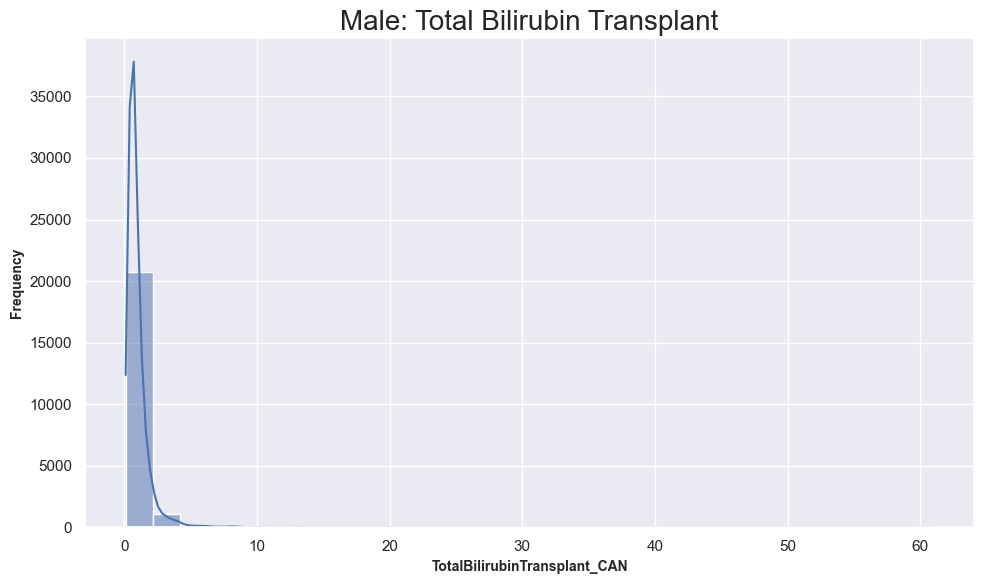

In [128]:
plot_histogram(df_m, 'TotalBilirubinTransplant_CAN', txt='Male: Total Bilirubin Transplant', bins=30)

In [129]:
u.check_informative_missingness(df_m, 'TotalBilirubinTransplant_CAN', txt='Male')

--- Missingness (Male): TotalBilirubinTransplant_CAN ---
Group Sizes:    (Unknown=83, Known=22,151)
Mean survival:  (Unknown=1,248.4d, Known=1,437.2d)
Difference:     -188.8 days

--- Welch's t-test Analysis ---
ρ-Value: 0.2553
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.1632 (Negligible)
95% CI:        [-0.3787, 0.0524]
Result: Likely Random Missingness (Effect size not significant)



In [130]:
u.continuous_value_predicts_survival(df_m, 'TotalBilirubinTransplant_CAN', txt='Male')

--- Value Predicts Survival (Male): TotalBilirubinTransplant_CAN ---
Pearson r=-0.040, p=2.77e-09 & Approx. Variance Explained=0.159%
Spearman r=0.001, p=0.931 & Approx. Variance Explained=0.000%



#### Female

In [131]:
# info
features = u.get_feature_info(df_f, 'TotalBilirubinTransplant', cat=False) 

                               count      mean       std  min  25%  50%  75%   max
TotalBilirubinTransplant_CAN  8029.0  0.902765  1.679297  0.1  0.4  0.6  1.0  80.0

:::: NaN Count:
TotalBilirubinTransplant_CAN    35 



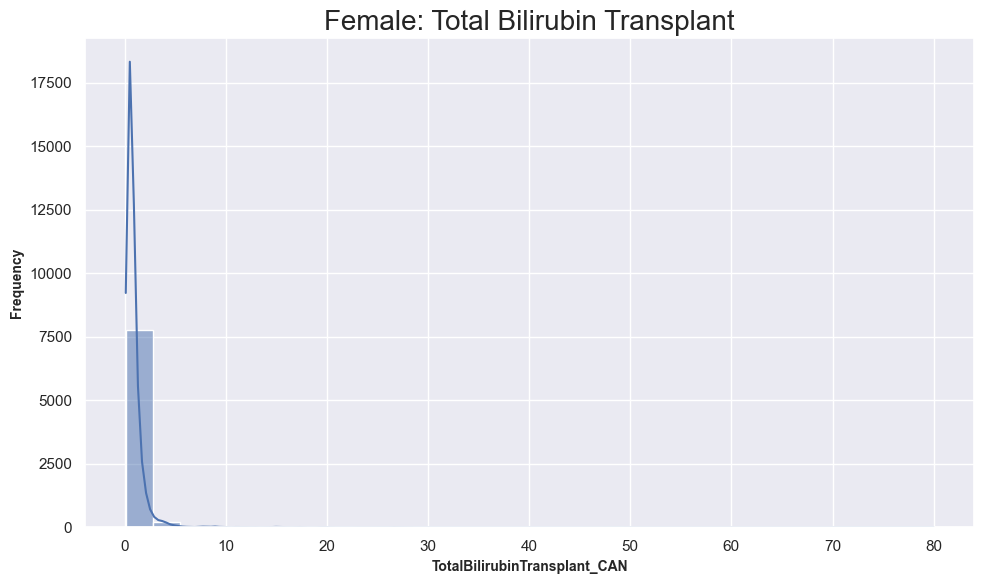

In [132]:
plot_histogram(df_f, 'TotalBilirubinTransplant_CAN', txt='Female: Total Bilirubin Transplant', bins=30)

In [133]:
u.check_informative_missingness(df_f, 'TotalBilirubinTransplant_CAN', txt='Female')

--- Missingness (Female): TotalBilirubinTransplant_CAN ---
Group Sizes:    (Unknown=35, Known=8,029)
Mean survival:  (Unknown=1,525.4d, Known=1,423.7d)
Difference:     101.7 days

--- Welch's t-test Analysis ---
ρ-Value: 0.6805
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     0.0882 (Negligible)
95% CI:        [-0.2439, 0.4202]
Result: Likely Random Missingness (Effect size not significant)



In [134]:
u.continuous_value_predicts_survival(df_f, 'TotalBilirubinTransplant_CAN', txt='Female')

--- Value Predicts Survival (Female): TotalBilirubinTransplant_CAN ---
Pearson r=-0.015, p=0.1724 & Approx. Variance Explained=0.023%
Spearman r=0.017, p=0.1354 & Approx. Variance Explained=0.028%



#### Log Transform

In [135]:
# Log Transform
df_m['TotalBilirubinTransplant_Log'] = np.log1p(df_m.TotalBilirubinTransplant_CAN)
# female
df_f['TotalBilirubinTransplant_Log'] = np.log1p(df_f.TotalBilirubinTransplant_CAN)
# remove
df_m = df_m.drop('TotalBilirubinTransplant_CAN', axis=1)
df_f = df_f.drop('TotalBilirubinTransplant_CAN', axis=1)

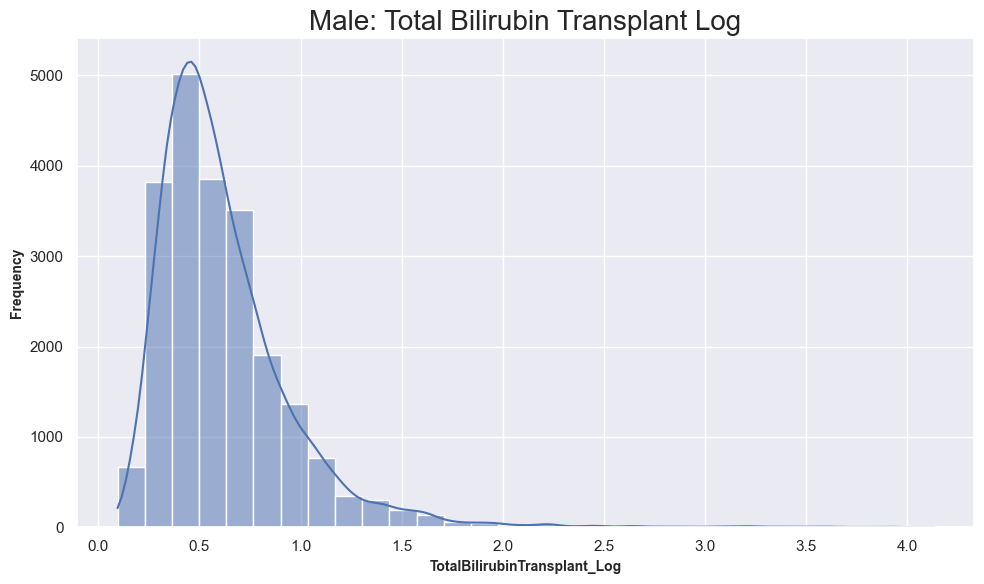

In [136]:
plot_histogram(df_m, 'TotalBilirubinTransplant_Log', txt='Male: Total Bilirubin Transplant Log', bins=30)

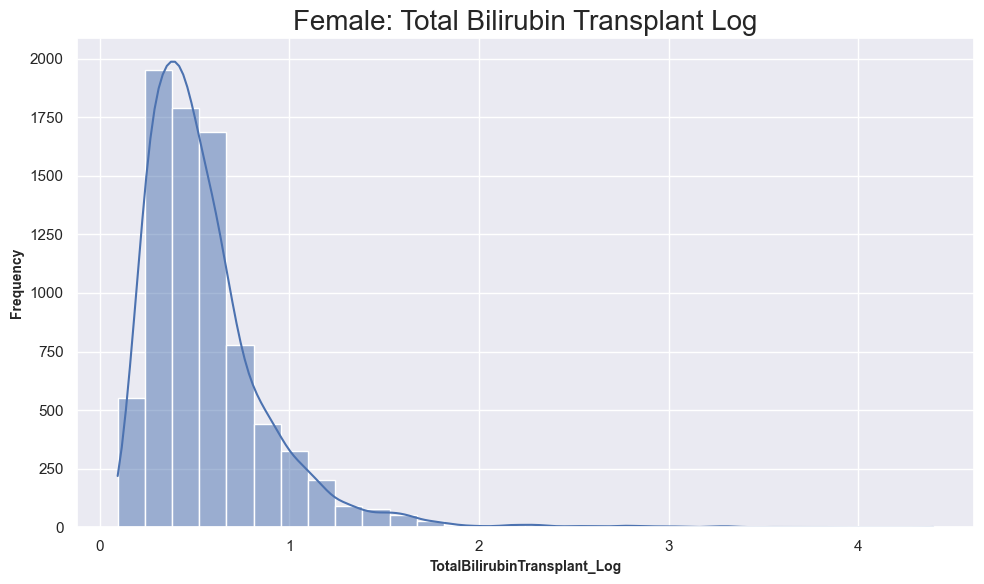

In [137]:
plot_histogram(df_f, 'TotalBilirubinTransplant_Log', txt='Female: Total Bilirubin Transplant Log', bins=30)

#### The "Shadow Variable" (Indicator) + Median Imputation

In [138]:
# impute: median and use new feature for NANS
df_m['TotalBilirubinTransplant_Log_IsMissing'] = df_m.TotalBilirubinTransplant_Log.isna().astype(int)
# female
df_f['TotalBilirubinTransplant_Log_IsMissing'] = df_f.TotalBilirubinTransplant_Log.isna().astype(int)
# median
df_m['TotalBilirubinTransplant_Log'] = df_m.TotalBilirubinTransplant_Log.fillna(df_m.TotalBilirubinTransplant_Log.median())
# female
df_f['TotalBilirubinTransplant_Log'] = df_f.TotalBilirubinTransplant_Log.fillna(df_f.TotalBilirubinTransplant_Log.median())
# sanity check
df_m['TotalBilirubinTransplant_Log_IsMissing'].sum(), df_f['TotalBilirubinTransplant_Log_IsMissing'].sum()

(np.int64(83), np.int64(35))

## BMI
$ \text{Metric System:} \space \text{Weight(kg)} \space / \space \text{Height(m)}^2$

### Male

In [139]:
# info
features = u.get_feature_info(df_m, 'BMI_', cat=False) 

                        count       mean          std      min       25%      50%      75%          max
BMI_Calc_CAN          22226.0  27.712904     4.775619  15.1000  24.30000  27.4000  31.0000      52.8000
BMI_Listing_CALC_CAN  22208.0  27.686991     4.736535  15.0000  24.20000  27.4000  31.0000      68.3000
BMI_Listing_CAN       22150.0  68.613684  3336.930855   2.9837  24.22295  27.4286  31.0178  318008.3102
BMI_Removal_CAN       22226.0  27.694740     4.669370  15.0000  24.30000  27.4000  31.0000      48.7000

:::: NaN Count:
BMI_Calc_CAN             8
BMI_Listing_CALC_CAN    26
BMI_Listing_CAN         84
BMI_Removal_CAN          8 



In [140]:
# check BMI unrealistic data
df_m.loc[df_m.BMI_Listing_CAN > 100, features + ['Weight_kg_Listing_CAN', 'Height_cm_Listing_CAN']]

,BMI_Calc_CAN,BMI_Listing_CALC_CAN,BMI_Listing_CAN,BMI_Removal_CAN,Weight_kg_Listing_CAN,Height_cm_Listing_CAN
4241,26.2,24.6,169.1919,24.6,68.7,167.0
14070,34.0,36.4,33257.9995,36.4,132.0,190.5
16633,24.8,30.1,276457.0637,27.7,103.4,185.4
16710,24.5,25.8,260207.6125,25.8,74.8,170.2
17252,32.8,33.4,318008.3102,32.8,114.8,185.4
21917,20.5,20.3,18611.1111,20.3,68.0,182.9


In [141]:
# get index and recalc BMI_Listing_CAN
idx = df_m.loc[df_m.BMI_Listing_CAN > 100, features + ['Weight_kg_Listing_CAN', 'Height_cm_Listing_CAN']].index
# update with correct BMI
df_m.loc[idx, 'BMI_Listing_CAN']  = np.round(
    df_m.loc[idx, 'Weight_kg_Listing_CAN'] /
    (df_m.loc[idx, 'Height_cm_Listing_CAN'] / 100) ** 2,
    4)

In [142]:
# sanity check
df_m.loc[idx, features + ['Weight_kg_Listing_CAN', 'Height_cm_Listing_CAN']]

,BMI_Calc_CAN,BMI_Listing_CALC_CAN,BMI_Listing_CAN,BMI_Removal_CAN,Weight_kg_Listing_CAN,Height_cm_Listing_CAN
4241,26.2,24.6,24.6334,24.6,68.7,167.0
14070,34.0,36.4,36.3734,36.4,132.0,190.5
16633,24.8,30.1,30.0816,27.7,103.4,185.4
16710,24.5,25.8,25.8216,25.8,74.8,170.2
17252,32.8,33.4,33.3982,32.8,114.8,185.4
21917,20.5,20.3,20.3274,20.3,68.0,182.9


In [143]:
# info
features = u.get_feature_info(df_m, 'BMI_', cat=False) 

                        count       mean       std      min      25%     50%        75%      max
BMI_Calc_CAN          22226.0  27.712904  4.775619  15.1000  24.3000  27.400  31.000000  52.8000
BMI_Listing_CALC_CAN  22208.0  27.686991  4.736535  15.0000  24.2000  27.400  31.000000  68.3000
BMI_Listing_CAN       22150.0  27.686341  4.798740   2.9837  24.2228  27.426  31.012675  79.7392
BMI_Removal_CAN       22226.0  27.694740  4.669370  15.0000  24.3000  27.400  31.000000  48.7000

:::: NaN Count:
BMI_Calc_CAN             8
BMI_Listing_CALC_CAN    26
BMI_Listing_CAN         84
BMI_Removal_CAN          8 



In [144]:
df_m[features].corr()

,BMI_Calc_CAN,BMI_Listing_CALC_CAN,BMI_Listing_CAN,BMI_Removal_CAN
BMI_Calc_CAN,1.000000,0.855381,0.848982,0.897418
BMI_Listing_CALC_CAN,0.855381,1.000000,0.989735,0.940107
BMI_Listing_CAN,0.848982,0.989735,1.000000,0.929035
BMI_Removal_CAN,0.897418,0.940107,0.929035,1.000000


In [145]:
# Use height & weight to calculate BMI
idx = df_m.loc[df_m.BMI_Calc_CAN.isna(), features + ['Weight_kg_CAN', 'Height_cm_CAN']].index
# update with correct BMI
df_m.loc[idx, 'BMI_Calc_CAN']  = np.round(
    df_m.loc[idx, 'Weight_kg_CAN'] /
    (df_m.loc[idx, 'Height_cm_CAN'] / 100) ** 2,
    1)

In [146]:
# Use height & weight to calculate BMI
idx = df_m.loc[df_m.BMI_Listing_CALC_CAN.isna(), features + ['Weight_kg_Listing_CAN', 'Height_cm_Listing_CAN']].index
# update with correct BMI
df_m.loc[idx, 'BMI_Listing_CALC_CAN']  = np.round(
    df_m.loc[idx, 'Weight_kg_Listing_CAN'] /
    (df_m.loc[idx, 'Height_cm_Listing_CAN'] / 100) ** 2,
    1)

In [147]:
# Use height & weight to calculate BMI
idx = df_m.loc[df_m.BMI_Listing_CAN.isna(), features + ['Weight_kg_Listing_CAN', 'Height_cm_Listing_CAN']].index
# update with correct BMI
df_m.loc[idx, 'BMI_Listing_CAN']  = np.round(
    df_m.loc[idx, 'Weight_kg_Listing_CAN'] /
    (df_m.loc[idx, 'Height_cm_Listing_CAN'] / 100) ** 2,
    4)

In [148]:
# Use height & weight to calculate BMI
idx = df_m.loc[df_m.BMI_Removal_CAN.isna(), features + ['Weight_kg_Removal_CAN', 'Height_cm_Removal_CAN']].index
# update with correct BMI
df_m.loc[idx, 'BMI_Removal_CAN']  = np.round(
    df_m.loc[idx, 'Weight_kg_Removal_CAN'] /
    (df_m.loc[idx, 'Height_cm_Removal_CAN'] / 100) ** 2,
    1)

In [149]:
# info
features = u.get_feature_info(df_m, 'BMI_', cat=False) 

                        count       mean       std      min       25%       50%      75%      max
BMI_Calc_CAN          22232.0  27.709311  4.779980  14.1000  24.30000  27.40000  31.0000  52.8000
BMI_Listing_CALC_CAN  22223.0  27.677798  4.748158  12.7000  24.20000  27.40000  31.0000  68.3000
BMI_Listing_CAN       22234.0  27.684804  4.796386   2.9837  24.22295  27.41985  31.0112  79.7392
BMI_Removal_CAN       22232.0  27.691112  4.673962  14.0000  24.30000  27.40000  31.0000  48.7000

:::: NaN Count:
BMI_Calc_CAN             2
BMI_Listing_CALC_CAN    11
BMI_Listing_CAN          0
BMI_Removal_CAN          2 



### Female

In [150]:
# info
features = u.get_feature_info(df_f, 'BMI_', cat=False) 

                       count       mean         std      min      25%      50%      75%        max
BMI_Calc_CAN          8059.0  26.917707    5.430065  15.1000  22.7000  26.5000  30.9000     48.800
BMI_Listing_CALC_CAN  8047.0  26.807059    5.353201  15.2000  22.7000  26.3000  30.7000     51.900
BMI_Listing_CAN       8033.0  32.035335  335.102774   9.2324  22.6551  26.3377  30.7275  23981.824
BMI_Removal_CAN       8059.0  26.815002    5.327932  15.2000  22.7000  26.4000  30.7000     46.200

:::: NaN Count:
BMI_Calc_CAN             5
BMI_Listing_CALC_CAN    17
BMI_Listing_CAN         31
BMI_Removal_CAN          5 



In [151]:
# check BMI unrealistic data
df_f.loc[df_f.BMI_Listing_CAN > 100, features + ['Weight_kg_Listing_CAN', 'Height_cm_Listing_CAN']]

,BMI_Calc_CAN,BMI_Listing_CALC_CAN,BMI_Listing_CAN,BMI_Removal_CAN,Weight_kg_Listing_CAN,Height_cm_Listing_CAN
14479,21.2,19.5,18140.000,19.5,45.4,152.4
21940,27.9,26.6,23981.824,26.6,74.8,167.6


In [152]:
# get index and recalc BMI_Listing_CAN
idx = df_f.loc[df_f.BMI_Listing_CAN > 100, features + ['Weight_kg_Listing_CAN', 'Height_cm_Listing_CAN']].index
# update with correct BMI
df_f.loc[idx, 'BMI_Listing_CAN']  = np.round(
    df_f.loc[idx, 'Weight_kg_Listing_CAN'] /
    (df_f.loc[idx, 'Height_cm_Listing_CAN'] / 100) ** 2,
    4)
# sanity check
df_f.loc[idx, features + ['Weight_kg_Listing_CAN', 'Height_cm_Listing_CAN']]

,BMI_Calc_CAN,BMI_Listing_CALC_CAN,BMI_Listing_CAN,BMI_Removal_CAN,Weight_kg_Listing_CAN,Height_cm_Listing_CAN
14479,21.2,19.5,19.5473,19.5,45.4,152.4
21940,27.9,26.6,26.6289,26.6,74.8,167.6


In [153]:
df_f[features].corr()

,BMI_Calc_CAN,BMI_Listing_CALC_CAN,BMI_Listing_CAN,BMI_Removal_CAN
BMI_Calc_CAN,1.000000,0.890495,0.890123,0.919668
BMI_Listing_CALC_CAN,0.890495,1.000000,0.996153,0.959284
BMI_Listing_CAN,0.890123,0.996153,1.000000,0.955792
BMI_Removal_CAN,0.919668,0.959284,0.955792,1.000000


In [154]:
# Use height & weight to calculate BMI
idx = df_f.loc[df_f.BMI_Calc_CAN.isna(), features + ['Weight_kg_CAN', 'Height_cm_CAN']].index
# update with correct BMI
df_f.loc[idx, 'BMI_Calc_CAN']  = np.round(
    df_f.loc[idx, 'Weight_kg_CAN'] /
    (df_f.loc[idx, 'Height_cm_CAN'] / 100) ** 2,
    1)

In [155]:
# Use height & weight to calculate BMI
idx = df_f.loc[df_f.BMI_Listing_CALC_CAN.isna(), features + ['Weight_kg_Listing_CAN', 'Height_cm_Listing_CAN']].index
# update with correct BMI
df_f.loc[idx, 'BMI_Listing_CALC_CAN']  = np.round(
    df_f.loc[idx, 'Weight_kg_Listing_CAN'] /
    (df_f.loc[idx, 'Height_cm_Listing_CAN'] / 100) ** 2,
    1)

In [156]:
# Use height & weight to calculate BMI
idx = df_f.loc[df_f.BMI_Listing_CAN.isna(), features + ['Weight_kg_Listing_CAN', 'Height_cm_Listing_CAN']].index
# update with correct BMI
df_f.loc[idx, 'BMI_Listing_CAN']  = np.round(
    df_f.loc[idx, 'Weight_kg_Listing_CAN'] /
    (df_f.loc[idx, 'Height_cm_Listing_CAN'] / 100) ** 2,
    4)

In [157]:
# Use height & weight to calculate BMI
idx = df_f.loc[df_f.BMI_Removal_CAN.isna(), features + ['Weight_kg_Removal_CAN', 'Height_cm_Removal_CAN']].index
# update with correct BMI
df_f.loc[idx, 'BMI_Removal_CAN']  = np.round(
    df_f.loc[idx, 'Weight_kg_Removal_CAN'] /
    (df_f.loc[idx, 'Height_cm_Removal_CAN'] / 100) ** 2,
    1)

In [158]:
# info
features = u.get_feature_info(df_f, 'BMI_', cat=False) 

                       count       mean       std      min      25%      50%     75%      max
BMI_Calc_CAN          8059.0  26.917707  5.430065  15.1000  22.7000  26.5000  30.900  48.8000
BMI_Listing_CALC_CAN  8052.0  26.799180  5.360888  12.9000  22.7000  26.3000  30.700  51.9000
BMI_Listing_CAN       8063.0  26.793397  5.384820   9.2324  22.6559  26.3339  30.725  49.9962
BMI_Removal_CAN       8059.0  26.815002  5.327932  15.2000  22.7000  26.4000  30.700  46.2000

:::: NaN Count:
BMI_Calc_CAN             5
BMI_Listing_CALC_CAN    12
BMI_Listing_CAN          1
BMI_Removal_CAN          5 



### Median

In [159]:
# impute: median
df_m[features] = df_m[features].fillna(df_m[features].median())
# female
df_f[features] = df_f[features].fillna(df_f[features].median())

### PCA

In [160]:
# scale for PCA (male)
X_scaled = StandardScaler().fit_transform(df_m[features].values)

# PCA
pca = PCA(n_components=0.9, random_state=SEED).fit(X_scaled)  # 90% variance
print(f"Components: {pca.n_components_}")
print(f"Explained variance: {pca.explained_variance_ratio_}")

# Add to dataframe
pca_scores = pca.transform(X_scaled)
for i in range(pca.n_components_):
    df_m[f'PC{i+1}_BMI_CAN'] = pca_scores[:, i]

# drop columns
df_m = df_m.drop(columns=features)
# shape
df_m.shape

Components: 1
Explained variance: [0.9317295]


(22234, 151)

In [161]:
# scale for PCA (female)
X_scaled = StandardScaler().fit_transform(df_f[features].values)

# PCA
pca = PCA(n_components=0.9, random_state=SEED).fit(X_scaled)  # 90% variance
print(f"Components: {pca.n_components_}")
print(f"Explained variance: {pca.explained_variance_ratio_}")

# Add to dataframe
pca_scores = pca.transform(X_scaled)
for i in range(pca.n_components_):
    df_f[f'PC{i+1}_BMI_CAN'] = pca_scores[:, i]

# drop columns
df_f = df_f.drop(columns=features)
# shape
df_f.shape

Components: 1
Explained variance: [0.95037169]


(8064, 145)

## Weight (Kg)

### Male

In [162]:
# info
features = u.get_feature_info(df_m, 'Weight', cat=False) 

                               count       mean        std     min      25%   50%        75%    max
Weight_kg_CAN                22232.0  87.540176  17.202229  33.600  75.3000  86.2  99.000000  162.1
Weight_kg_Listing_CAN        22223.0  87.509936  17.147791  31.200  75.1000  86.4  99.200000  182.5
Weight_kg_Registrsation_CAN  22200.0  87.531287  17.299069   9.979  75.0925  86.5  99.293475  271.0
Weight_kg_Removal_CAN        22232.0  87.521213  16.936988  29.900  75.3000  86.6  98.900000  165.1

:::: NaN Count:
Weight_kg_CAN                   2
Weight_kg_Listing_CAN          11
Weight_kg_Registrsation_CAN    34
Weight_kg_Removal_CAN           2 



In [163]:
df_m[features].corr()

,Weight_kg_CAN,Weight_kg_Listing_CAN,Weight_kg_Registrsation_CAN,Weight_kg_Removal_CAN
Weight_kg_CAN,1.000000,0.896875,0.892847,0.929621
Weight_kg_Listing_CAN,0.896875,1.000000,0.993181,0.954214
Weight_kg_Registrsation_CAN,0.892847,0.993181,1.000000,0.947812
Weight_kg_Removal_CAN,0.929621,0.954214,0.947812,1.000000


### Female

In [164]:
# info
features = u.get_feature_info(df_f, 'Weight', cat=False) 

                              count       mean        std     min     25%    50%      75%       max
Weight_kg_CAN                8059.0  71.817198  15.937718  31.900  59.600  70.30  82.7000  148.0000
Weight_kg_Listing_CAN        8053.0  71.556339  15.766272  32.500  59.400  70.00  82.1000  143.3000
Weight_kg_Registrsation_CAN  8048.0  71.536680  15.853206  25.946  59.421  70.09  82.1002  143.3351
Weight_kg_Removal_CAN        8059.0  71.552041  15.694035  32.500  59.400  70.30  82.2000  143.3000

:::: NaN Count:
Weight_kg_CAN                   5
Weight_kg_Listing_CAN          11
Weight_kg_Registrsation_CAN    16
Weight_kg_Removal_CAN           5 



In [165]:
df_f[features].corr()

,Weight_kg_CAN,Weight_kg_Listing_CAN,Weight_kg_Registrsation_CAN,Weight_kg_Removal_CAN
Weight_kg_CAN,1.000000,0.919282,0.918192,0.942370
Weight_kg_Listing_CAN,0.919282,1.000000,0.998342,0.968052
Weight_kg_Registrsation_CAN,0.918192,0.998342,1.000000,0.965822
Weight_kg_Removal_CAN,0.942370,0.968052,0.965822,1.000000


### Median

In [166]:
# impute: median
df_m[features] = df_m[features].fillna(df_m[features].median())
# female
df_f[features] = df_f[features].fillna(df_f[features].median())

### PCA

In [167]:
# scale for PCA (male)
X_scaled = StandardScaler().fit_transform(df_m[features].values)

# PCA
pca = PCA(n_components=0.9, random_state=SEED).fit(X_scaled)  # 90% variance
print(f"Components: {pca.n_components_}")
print(f"Explained variance: {pca.explained_variance_ratio_}")

# Add to dataframe
pca_scores = pca.transform(X_scaled)
for i in range(pca.n_components_):
    df_m[f'PC{i+1}_weight_CAN'] = pca_scores[:, i]

# drop columns
df_m = df_m.drop(columns=features)
# shape
df_m.shape

Components: 1
Explained variance: [0.95092481]


(22234, 148)

In [168]:
# scale for PCA (female)
X_scaled = StandardScaler().fit_transform(df_f[features].values)

# PCA
pca = PCA(n_components=0.9, random_state=SEED).fit(X_scaled)  # 90% variance
print(f"Components: {pca.n_components_}")
print(f"Explained variance: {pca.explained_variance_ratio_}")

# Add to dataframe
pca_scores = pca.transform(X_scaled)
for i in range(pca.n_components_):
    df_f[f'PC{i+1}_weight_CAN'] = pca_scores[:, i]

# drop columns
df_f = df_f.drop(columns=features)
# shape
df_f.shape

Components: 1
Explained variance: [0.96277395]


(8064, 142)

## Height

### Male

In [169]:
# info
features = u.get_feature_info(df_m, 'Height', cat=False) 

                              count        mean       std    min    25%    50%    75%    max
Height_cm_CAN               22234.0  177.517293  7.951639  124.0  172.7  177.8  182.9  210.8
Height_cm_Listing_CAN       22234.0  177.582378  7.975324  124.0  172.7  177.8  182.9  221.0
Height_cm_Registration_CAN  22152.0  177.545323  8.392704    2.0  173.0  178.0  183.0  221.0
Height_cm_Removal_CAN       22234.0  177.548673  7.894664  124.0  172.7  177.8  182.9  213.4

:::: NaN Count:
Height_cm_CAN                  0
Height_cm_Listing_CAN          0
Height_cm_Registration_CAN    82
Height_cm_Removal_CAN          0 



In [170]:
df_m[features].corr()

,Height_cm_CAN,Height_cm_Listing_CAN,Height_cm_Registration_CAN,Height_cm_Removal_CAN
Height_cm_CAN,1.000000,0.939609,0.887941,0.950777
Height_cm_Listing_CAN,0.939609,1.000000,0.936555,0.985470
Height_cm_Registration_CAN,0.887941,0.936555,1.000000,0.926455
Height_cm_Removal_CAN,0.950777,0.985470,0.926455,1.000000


### Female

In [171]:
# info
features = u.get_feature_info(df_f, 'Height', cat=False) 

                             count        mean       std    min    25%    50%    75%    max
Height_cm_CAN               8064.0  163.157626  7.311861  129.0  157.5  162.6  167.6  200.7
Height_cm_Listing_CAN       8063.0  163.215974  7.331630  124.5  157.5  162.6  167.6  200.7
Height_cm_Registration_CAN  8033.0  163.190962  7.786902    5.0  157.0  163.0  168.0  218.0
Height_cm_Removal_CAN       8064.0  163.153534  7.237262  124.5  157.5  162.6  167.6  195.6

:::: NaN Count:
Height_cm_CAN                  0
Height_cm_Listing_CAN          1
Height_cm_Registration_CAN    31
Height_cm_Removal_CAN          0 



In [172]:
df_f[features].corr()

,Height_cm_CAN,Height_cm_Listing_CAN,Height_cm_Registration_CAN,Height_cm_Removal_CAN
Height_cm_CAN,1.000000,0.924603,0.881273,0.940596
Height_cm_Listing_CAN,0.924603,1.000000,0.938597,0.979933
Height_cm_Registration_CAN,0.881273,0.938597,1.000000,0.927888
Height_cm_Removal_CAN,0.940596,0.979933,0.927888,1.000000


### Median

In [173]:
# impute: median
df_m[features] = df_m[features].fillna(df_m[features].median())
# female
df_f[features] = df_f[features].fillna(df_f[features].median())

### PCA

In [174]:
# scale for PCA (male)
X_scaled = StandardScaler().fit_transform(df_m[features].values)

# PCA
pca = PCA(n_components=0.9, random_state=SEED).fit(X_scaled)  # 90% variance
print(f"Components: {pca.n_components_}")
print(f"Explained variance: {pca.explained_variance_ratio_}")

# Add to dataframe
pca_scores = pca.transform(X_scaled)
for i in range(pca.n_components_):
    df_m[f'PC{i+1}_height_CAN'] = pca_scores[:, i]

# drop columns
df_m = df_m.drop(columns=features)
# shape
df_m.shape

Components: 1
Explained variance: [0.95278022]


(22234, 145)

In [175]:
# scale for PCA (female)
X_scaled = StandardScaler().fit_transform(df_f[features].values)

# PCA
pca = PCA(n_components=0.9, random_state=SEED).fit(X_scaled)  # 90% variance
print(f"Components: {pca.n_components_}")
print(f"Explained variance: {pca.explained_variance_ratio_}")

# Add to dataframe
pca_scores = pca.transform(X_scaled)
for i in range(pca.n_components_):
    df_f[f'PC{i+1}_height_CAN'] = pca_scores[:, i]

# drop columns
df_f = df_f.drop(columns=features)
# shape
df_f.shape

Components: 1
Explained variance: [0.94857219]


(8064, 139)

In [176]:
# check for NaNs
df_m.isna().any().any(), df_f.isna().any().any()

(np.True_, np.False_)

#### Write to Disk: Candidate Data

In [177]:
# save data: heart dataset
u.write_to_file(df_f, 'Candidate_Female_Heart',path='../Data/', format='pkl')
u.write_to_file(df_m, 'Candidate_Male_Heart',path='../Data/', format='pkl')

8,064 records written to ../Data/Candidate_Female_Heart.pkl
22,234 records written to ../Data/Candidate_Male_Heart.pkl
